# Analisis Descriptivo Univariado — Dataset Competentes

**Fuente**: `data/ia_comp.xlsx` (503 encuestas a personas en busqueda de empleo / interesadas
en mejorar su empleabilidad)

**Objetivo (Pipeline Step 3)**: replicar la estructura del analisis univariado del dataset
PyMEs (Step 2) sobre el dataset de Competentes — tablas de frecuencia, graficos de barras y
analisis de valores faltantes — incluyendo el tratamiento especifico del bloque de respuesta
multiple `p_02a`–`p_02e` (apoyo requerido en la busqueda de empleo), para permitir comparaciones
directas entre ambos datasets en etapas posteriores (Steps 6 y 11).

## Tabla de contenidos

1. [Notas de preparacion de datos](#1.-Notas-de-preparacion-de-datos)
2. [Resumen del dataset](#2.-Resumen-del-dataset)
3. [Perfil demografico](#3.-Perfil-demografico)
    - [3.1 Sexo](#3.1-Sexo)
    - [3.2 Rango etario (edad)](#3.2-Rango-etario-(edad))
    - [3.3 Nivel educacional (niveduc)](#3.3-Nivel-educacional-(niveduc))
    - [3.4 Ocupacion](#3.4-Ocupacion)
    - [3.5 Grupo socioeconomico (nse)](#3.5-Grupo-socioeconomico-(nse))
4. [Variables de respuesta de busqueda de empleo](#4.-Variables-de-respuesta-de-busqueda-de-empleo)
    - [4.1 p01 — Principal barrera para aprender herramientas digitales](#4.1-p01-—-Principal-barrera-para-aprender-herramientas-digitales)
    - [4.2 p_02a–p_02e — Apoyo requerido en la busqueda de empleo (multi-respuesta)](#4.2-p_02a–p_02e-—-Apoyo-requerido-en-la-busqueda-de-empleo-(multi-respuesta))
    - [4.3 p03 — Interes en formacion de habilidades via movil](#4.3-p03-—-Interes-en-formacion-de-habilidades-via-movil)
5. [Analisis de valores faltantes](#5.-Analisis-de-valores-faltantes)
6. [Resumen de hallazgos clave](#6.-Resumen-de-hallazgos-clave)


## 1. Notas de preparacion de datos

Este notebook reutiliza los mismos helpers (`analysis_helpers.py`) validados y corregidos
durante el analisis de PyMEs (Step 2). A diferencia de `PYMES_CODES`, la lista `COMP_CODES` ya
declaraba los 15 codigos correctos desde el Step 1 (5 demograficos + `p01`/`p01_otro` +
`p_02a`–`p_02e` + `p02_otro` + `p03`), por lo que **no fue necesario corregir el mapeo de
columnas** para este dataset — el rename map generado por `build_rename_map()` calza 1:1 con el
diccionario documentado en `CLAUDE.md`.

Se heredan automaticamente (por ser correcciones a nivel de helper, no de dataset) los tres
ajustes ya aplicados en el Step 2:

1. `lowercase_df()` normaliza columnas de texto en pandas 3.0 (dtype `str`, no solo `object`).
2. `normalize_text()` colapsa espacios alrededor de guiones (`"[31 - 40]"` → `"[31-40]"`) para
   que `edad` ordene correctamente.
3. `CATEGORY_ORDERS["niveduc"]` incluye los extremos `basica incompleta/completa` y `postgrado`.

Dos observaciones especificas de este dataset:

- **`ocupacion` conserva las mismas 3 categorias fuera del orden jerarquico documentado**
  (`alto(a) ejecutivo(a)`, `ejecutivo(a) medio(a) / profesional independiente`,
  `trabajos menores e informales`), que en conjunto representan **29.2% de la muestra** — ver
  Seccion 3.4.
- **`edad` no registra ningun respondente en el tramo `[61+]`** de los 5 niveles canonicos
  definidos en `CATEGORY_ORDERS`; la categoria queda automaticamente excluida del eje del
  grafico de barras al no estar observada (`apply_categoricals` solo incluye niveles presentes
  en los datos) — ver Seccion 3.2.


In [1]:
from analysis_helpers import *
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

dfcomp = load_survey(COMP_PATH, COMP_CODES, dataset="comp")
set_theme("light")


Rename map (raw header -> code):
  id         <- 'ID'
  sexo       <- 'SEXO'
  edad       <- 'RANGO ETARIO'
  niveduc    <- '¿NIVEL EDUCACIONAL?'
  ocupacion  <- '¿TIPO DE TRABAJO?'
  nse        <- 'GRUPO NSE'
  p01        <- '¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total)'
  p01_otro   <- '¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique))'
  p_02a      <- 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Armar o mejorar mi CV)'
  p_02b      <- 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prepararme para una entrevista)'
  p_02c      <- 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Buscar ofertas de trabajo)'
  p_02d      <- 'En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda

/Users/tomas/github/icd_ia/analysis_helpers.py:357: UserWarning: Column 'ocupacion' has 3 value(s) outside the canonical ordering: ['alto(a) ejecutivo(a)', 'ejecutivo(a) medio(a) / profesional independiente', 'trabajos menores e informales'] -- appended as trailing categories.
  df = apply_categoricals(df, strict=strict, verbose=verbose)


<module 'matplotlib.pyplot' from '/Users/tomas/.pyenv/versions/datascience/lib/python3.14/site-packages/matplotlib/pyplot.py'>

## 2. Resumen del dataset

Vista general de columnas, tipos de dato y completitud antes de entrar al detalle
variable por variable.

In [2]:
labeled_info(dfcomp)

,code,label,dtype,n_valid,n_missing,pct_missing,n_unique
0,id,ID,int64,503,0,0.0,503
1,sexo,SEXO,category,503,0,0.0,2
2,edad,RANGO ETARIO,category,503,0,0.0,4
3,niveduc,¿NIVEL EDUCACIONAL?,category,503,0,0.0,8
4,ocupacion,¿TIPO DE TRABAJO?,category,503,0,0.0,10
5,nse,GRUPO NSE,category,503,0,0.0,4
6,p01,¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total),str,503,0,0.0,6
7,p01_otro,¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique)),float64,0,503,100.0,0
8,p_02a,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Arma...",str,189,314,62.4,1
9,p_02b,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prep...",str,152,351,69.8,1


In [3]:
labeled_head(dfcomp, 5)

,id\nID,sexo\nSEXO,edad\nRANGO ETARIO,niveduc\n¿NIVEL EDUCACIONAL?,ocupacion\n¿TIPO DE TRABAJO?,nse\nGRUPO NSE,p01\n¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total),p01_otro\n¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique)),"p_02a\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Armar o mejorar mi CV)","p_02b\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prepararme para una entrevista)","p_02c\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Buscar ofertas de trabajo)","p_02d\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Contactar empresas)","p_02e\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Ninguna / no necesito ayuda)","p02_otro\nEn el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Otro (especifique))",p03\n¿Te parecería atractivo aprender nuevas habilidades para mejorar tu empleabilidad en lecciones cortas a través de tu celular?
0,1,masculino,[41-50],tecnica superior completa,empleado(a) administrativo(a) / tecnico,c2,falta de tiempo,NaN,NaN,NaN,buscar ofertas de trabajo,NaN,NaN,NaN,sí
1,2,femenino,[41-50],media completa,oficio calificado,c3,falta de tiempo,NaN,NaN,prepararme para una entrevista,NaN,NaN,NaN,NaN,sí
2,3,femenino,[31-40],universitaria incompleta,cesante,c3,nada me frena,NaN,armar o mejorar mi cv,NaN,NaN,NaN,NaN,NaN,sí
3,4,femenino,[41-50],media completa,dueño(a) de casa,d+e,falta de confianza / me da inseguridad,NaN,NaN,prepararme para una entrevista,NaN,NaN,NaN,NaN,sí
4,5,masculino,[31-40],tecnica superior incompleta,oficio menor,c3,falta de tiempo,NaN,NaN,prepararme para una entrevista,NaN,NaN,NaN,NaN,sí


### Interpretacion — Resumen del dataset (Hallazgo 1)

El dataset tiene **503 respuestas y 15 columnas**: 5 variables demograficas (`sexo`, `edad`,
`niveduc`, `ocupacion`, `nse`), 2 preguntas cerradas (`p01`, `p03`), un bloque de 5 columnas de
respuesta multiple (`p_02a`–`p_02e`, apoyo requerido en la busqueda de empleo) y 2 campos de
texto libre "otro" (`p01_otro`, `p02_otro`). Las 6 variables cerradas de uso directo
(`sexo`, `edad`, `niveduc`, `ocupacion`, `p01`, `p03`) tienen **0% de valores faltantes**; `nse`
tiene **1 caso sin dato (0.2%)**, el unico faltante entre las variables demograficas — a
diferencia de PyMEs, donde `nse` estaba 100% completa. Los 2 campos "otro" estan **100%
vacios**, igual que en PyMEs. Las 5 columnas `p_02a`–`p_02e` muestran un patron de faltantes
muy distinto (60%–88.7%) que **no representa no-respuesta**, sino la codificacion habitual de
preguntas de opcion multiple: `NaN` significa "opcion no seleccionada" (ver Seccion 4.2 y 5).

## 3. Perfil demografico

### 3.1 Sexo

In [4]:
tbl_sexo = labeled_value_counts_detailed(dfcomp, "sexo")
tbl_sexo

sexo - SEXO   (n = 503)
------------------------------------------------------------------------
  femenino                             255   50.7%  ##############################
  masculino                            248   49.3%  #############################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,femenino,255,50.7,50.7,50.7
1,masculino,248,49.3,49.3,100.0


findfont: Failed to find font weight semibold, now using 700.


'/Users/tomas/github/icd_ia/figures/comp/comp_sexo_bar.png'

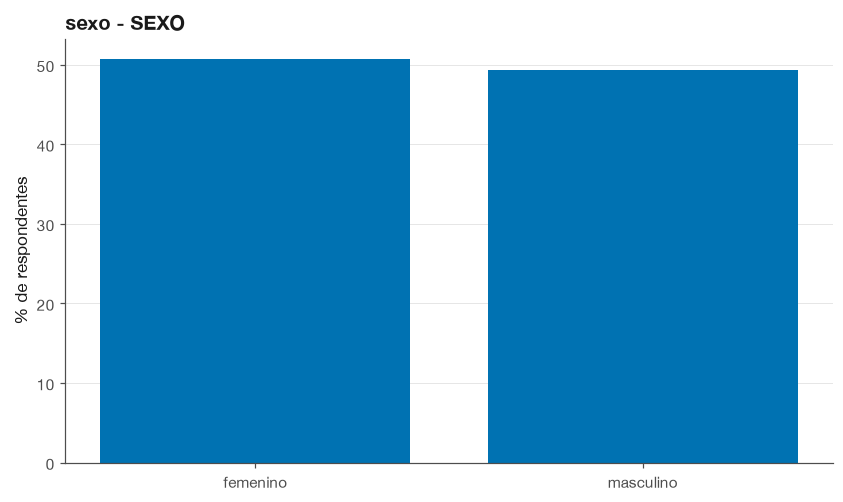

In [5]:
ax = bar_freq(dfcomp, "sexo", horizontal=False)
save_fig(ax, "comp_sexo_bar.png", subdir="comp")

**Interpretacion (Hallazgo 2):** la muestra esta **practicamente equilibrada por
genero** (50.7% femenino vs. 49.3% masculino, 255 vs. 248 respondentes), en linea con el
equilibrio observado en PyMEs (52.2%/47.8%), por lo que el sexo no introduce un sesgo relevante
para las comparaciones entre datasets en etapas posteriores.

### 3.2 Rango etario (edad)

In [6]:
tbl_edad = labeled_value_counts_detailed(dfcomp, "edad")
tbl_edad

edad - RANGO ETARIO   (n = 503)
------------------------------------------------------------------------
  [18-30]                               65   12.9%  ############
  [31-40]                              142   28.2%  ###########################
  [41-50]                              157   31.2%  ##############################
  [51-60]                              139   27.6%  ###########################
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,[18-30],65,12.9,12.9,12.9
1,[31-40],142,28.2,28.2,41.1
2,[41-50],157,31.2,31.2,72.3
3,[51-60],139,27.6,27.6,99.9


'/Users/tomas/github/icd_ia/figures/comp/comp_edad_bar.png'

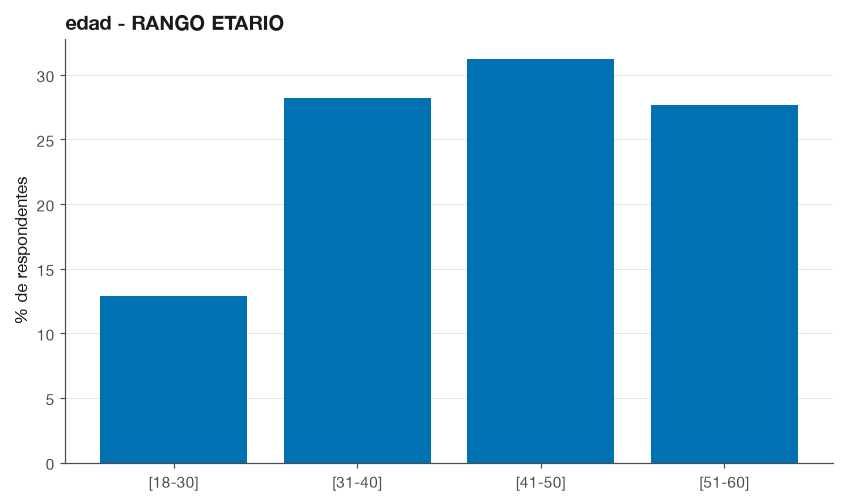

In [7]:
ax = bar_freq(dfcomp, "edad", horizontal=False)
save_fig(ax, "comp_edad_bar.png", subdir="comp")

**Interpretacion (Hallazgo 3):** la edad se concentra en los **tramos intermedios**:
`[41-50]` (31.2%) y `[31-40]` (28.2%) son los mas numerosos, seguidos de cerca por `[51-60]`
(27.6%); el tramo joven `[18-30]` es minoritario (12.9%). El hallazgo mas notable es
**estructural**: no hay ningun respondente en `[61+]`, el tramo de mayor edad del orden
canonico (que en PyMEs concentraba 19.8% de la muestra). Esto es consistente con el foco del
instrumento en personas activamente buscando empleo o mejorando su empleabilidad, un perfil
menos frecuente en la poblacion de 61 años o mas.

### 3.3 Nivel educacional (niveduc)

In [8]:
tbl_niveduc = labeled_value_counts_detailed(dfcomp, "niveduc")
tbl_niveduc

niveduc - ¿NIVEL EDUCACIONAL?   (n = 503)
------------------------------------------------------------------------
  basica completa                        1    0.2%  
  media incompleta                       2    0.4%  
  media completa                       114   22.7%  #######################
  tecnica superior incompleta           51   10.1%  ##########
  tecnica superior completa            105   20.9%  #####################
  universitaria incompleta              52   10.3%  ##########
  universitaria completa               150   29.8%  ##############################
  postgrado                             28    5.6%  ######
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,basica completa,1,0.2,0.2,0.2
1,media incompleta,2,0.4,0.4,0.6
2,media completa,114,22.7,22.7,23.3
3,tecnica superior incompleta,51,10.1,10.1,33.4
4,tecnica superior completa,105,20.9,20.9,54.3
5,universitaria incompleta,52,10.3,10.3,64.6
6,universitaria completa,150,29.8,29.8,94.4
7,postgrado,28,5.6,5.6,100.0


'/Users/tomas/github/icd_ia/figures/comp/comp_niveduc_bar.png'

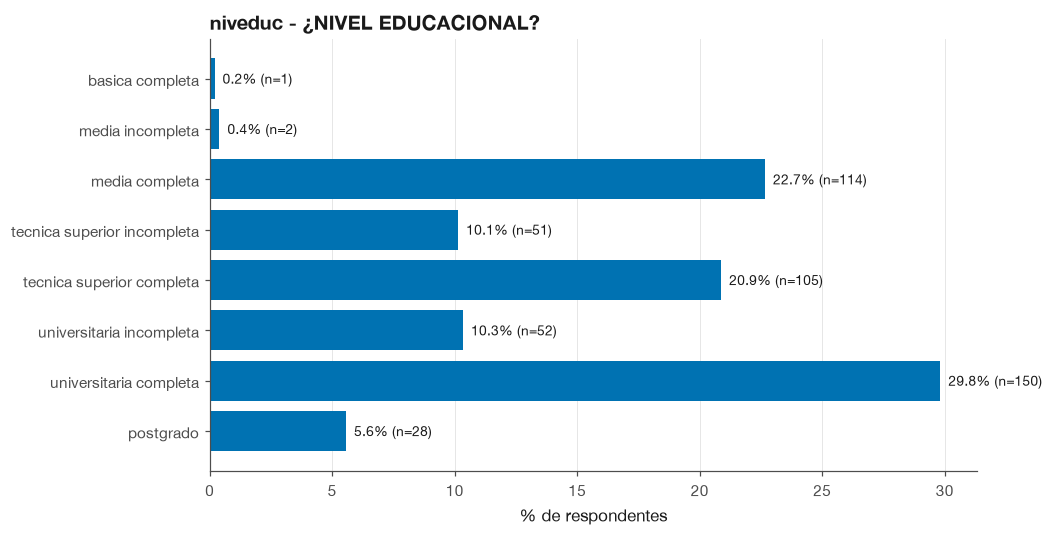

In [9]:
ax = bar_freq(dfcomp, "niveduc", horizontal=True)
save_fig(ax, "comp_niveduc_bar.png", subdir="comp")

**Interpretacion (Hallazgo 4):** el nivel educacional muestra una **mayoria clara de
formacion post-secundaria**: sumando tecnica superior (completa+incompleta, 31.0%) y
universitaria (completa+incompleta, 40.1%), el **71.1%** de la muestra tiene formacion
post-secundaria, y si se agrega postgrado (5.6%) el total con formacion terciaria o superior
sube a **76.7%** — un nivel educativo levemente mas alto que en PyMEs (70.7%). La educacion
basica es marginal (0.6% combinado, apenas 3 casos) y "media completa" es el tercer nivel mas
frecuente (22.7%), consistente con un perfil orientado a empleabilidad y busqueda activa de
mejores oportunidades laborales.

### 3.4 Ocupacion

In [10]:
tbl_ocupacion = labeled_value_counts_detailed(dfcomp, "ocupacion")
tbl_ocupacion

ocupacion - ¿TIPO DE TRABAJO?   (n = 503)
------------------------------------------------------------------------
  cesante                               51   10.1%  ##########
  estudiante                            19    3.8%  ####
  dueño(a) de casa                      29    5.8%  ######
  jubilado(a)                            6    1.2%  #
  oficio menor                          29    5.8%  ######
  oficio calificado                     67   13.3%  #############
  empleado(a) administrativo(a) /      155   30.8%  ##############################
  alto(a) ejecutivo(a)                  12    2.4%  ##
  ejecutivo(a) medio(a) / profesio      86   17.1%  #################
  trabajos menores e informales         49    9.7%  #########
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,cesante,51,10.1,10.1,10.1
1,estudiante,19,3.8,3.8,13.9
2,dueño(a) de casa,29,5.8,5.8,19.7
3,jubilado(a),6,1.2,1.2,20.9
4,oficio menor,29,5.8,5.8,26.7
5,oficio calificado,67,13.3,13.3,40.0
6,empleado(a) administrativo(a) / tecnico,155,30.8,30.8,70.8
7,alto(a) ejecutivo(a),12,2.4,2.4,73.2
8,ejecutivo(a) medio(a) / profesional independiente,86,17.1,17.1,90.3
9,trabajos menores e informales,49,9.7,9.7,100.0


'/Users/tomas/github/icd_ia/figures/comp/comp_ocupacion_bar.png'

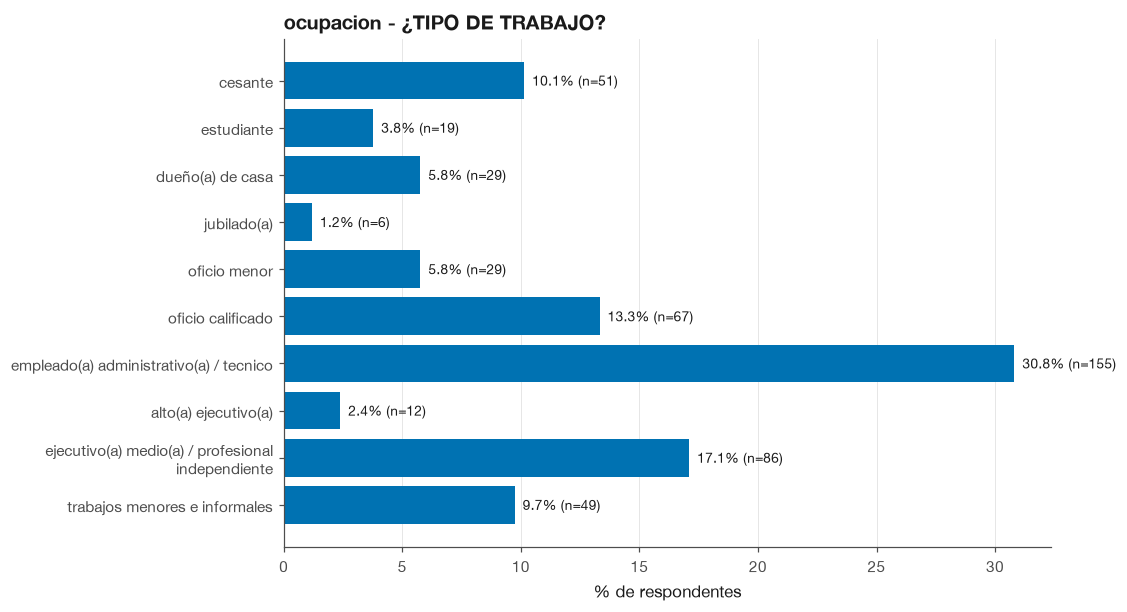

In [11]:
ax = bar_freq(dfcomp, "ocupacion", horizontal=True)
save_fig(ax, "comp_ocupacion_bar.png", subdir="comp")

**Interpretacion (Hallazgo 5):** la categoria mas frecuente es "empleado(a)
administrativo(a) / tecnico" (30.8%), seguida de "ejecutivo(a) medio(a) / profesional
independiente" (17.1%) y "oficio calificado" (13.3%). Un hallazgo relevante para el diseño de
intervenciones es que **solo 10.1% declara estar cesante** (desempleado/a): la mayoria de la
muestra de "competentes" ya esta empleada y busca **mejorar su empleabilidad o cambiar de
trabajo**, no encontrar un primer empleo. **Nota de calidad de datos (igual que en PyMEs):** las
3 categorias fuera del orden jerarquico documentado ("alto(a) ejecutivo(a)" 2.4%,
"ejecutivo(a) medio(a) / profesional independiente" 17.1%, "trabajos menores e informales" 9.7%)
suman **29.2%** de la muestra y requieren definicion de negocio antes de tratarse como escala
ordinal (ver Seccion 1).

### 3.5 Grupo socioeconomico (nse)

In [12]:
tbl_nse = labeled_value_counts_detailed(dfcomp, "nse")
tbl_nse

nse - GRUPO NSE   (n = 503)
------------------------------------------------------------------------
  d+e                                   49    9.7%  #######
  c3                                   144   28.6%  ####################
  c2                                   218   43.3%  ##############################
  abc1                                  92   18.3%  #############
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,d+e,49,9.7,9.7,9.7
1,c3,144,28.6,28.6,38.3
2,c2,218,43.3,43.3,81.6
3,abc1,92,18.3,18.3,99.9


'/Users/tomas/github/icd_ia/figures/comp/comp_nse_bar.png'

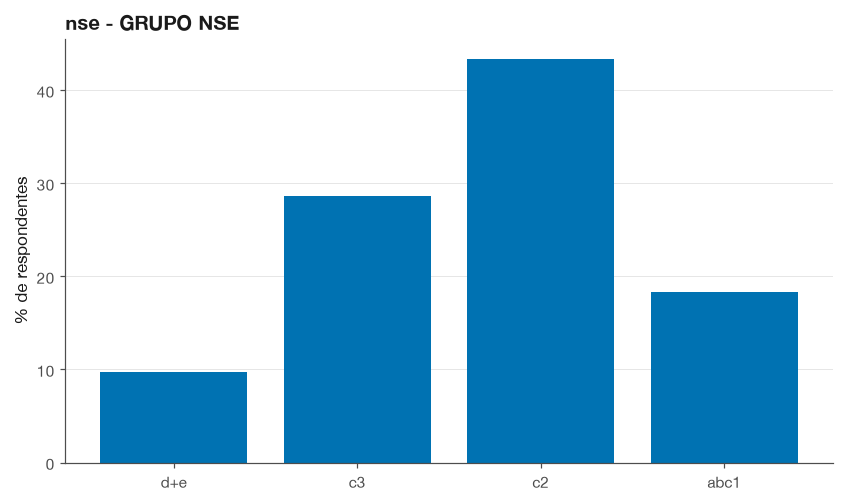

In [13]:
ax = bar_freq(dfcomp, "nse", horizontal=False)
save_fig(ax, "comp_nse_bar.png", subdir="comp")

**Interpretacion (Hallazgo 6):** el grupo socioeconomico esta **fuertemente
concentrado en el segmento medio** (c2 43.4% + c3 28.7% = 72.1% de los casos validos), una
concentracion aun mayor que en PyMEs (68.8%). Los extremos son minoritarios: d+e (9.8%) y abc1
(18.1%). A diferencia de PyMEs (0 faltantes), `nse` tiene **1 respondente sin dato** en este
dataset (0.2%), el unico valor faltante entre las variables demograficas.

## 4. Variables de respuesta de busqueda de empleo

### 4.1 p01 — Principal barrera para aprender herramientas digitales

In [14]:
tbl_p01 = labeled_value_counts_detailed(dfcomp, "p01")
tbl_p01

p01 - ¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Total)   (n = 503)
------------------------------------------------------------------------
  falta de tiempo                      179   35.6%  ##############################
  nada me frena                        163   32.4%  ###########################
  falta de confianza / me da inseg      50    9.9%  ########
  falta de conocimientos o habilid      88   17.5%  ###############
  falta de equipo o conexión a int      16    3.2%  ###
  no le veo utilidad para mi traba       7    1.4%  #
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,falta de tiempo,179,35.6,35.6,35.6
1,nada me frena,163,32.4,32.4,68.0
2,falta de confianza / me da inseguridad,50,9.9,9.9,77.9
3,falta de conocimientos o habilidades,88,17.5,17.5,95.4
4,falta de equipo o conexión a internet,16,3.2,3.2,98.6
5,no le veo utilidad para mi trabajo,7,1.4,1.4,100.0


'/Users/tomas/github/icd_ia/figures/comp/comp_p01_bar.png'

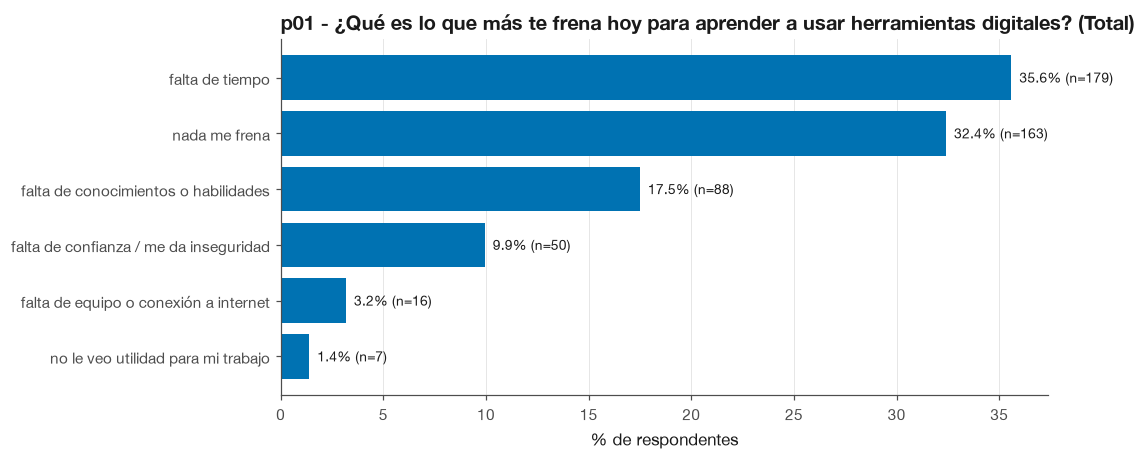

In [15]:
ax = bar_freq(dfcomp, "p01", horizontal=True)
save_fig(ax, "comp_p01_bar.png", subdir="comp")

**Interpretacion (Hallazgo 7):** la distribucion de barreras es **marcadamente
bimodal**: "falta de tiempo" (35.6%) y "nada me frena" (32.4%) concentran juntas el **68.0%**
de las respuestas, con una diferencia de solo 3.2 puntos porcentuales entre ambas. Le siguen
"falta de conocimientos o habilidades" (17.5%) y "falta de confianza / me da inseguridad"
(9.9%); las barreras estructurales —"falta de equipo o conexion a internet" (3.2%) y "no le veo
utilidad para mi trabajo" (1.4%)— son minoritarias. A diferencia de PyMEs, donde una sola
barrera ("falta de capital", 60.3%) domina claramente, aqui **casi un tercio de la muestra no
percibe ninguna barrera relevante**, lo que sugiere que la principal palanca de intervencion es
la gestion del tiempo disponible, mas que el acceso a equipamiento o la confianza.

### 4.2 p_02a–p_02e — Apoyo requerido en la busqueda de empleo (multi-respuesta)

Este bloque es de **respuesta multiple**: cada respondente pudo seleccionar cero, una o
varias opciones de apoyo. Por eso se analiza con `multiselect_summary()` en vez de
`freq_table()`/`bar_freq()` — cada columna es binaria (seleccionada / no seleccionada) y las
tasas de seleccion no suman 100%.

In [16]:
ms_p02 = multiselect_summary(dfcomp, COMP_MULTISELECT)
ms_p02

Respondents: 503 | selections per respondent: mean 1.43, max 4


,code,label,n_selected,pct_of_respondents
0,p_02a,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Arma...",189,37.6
1,p_02b,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prep...",152,30.2
2,p_02c,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Busc...",201,40.0
3,p_02d,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Cont...",120,23.9
4,p_02e,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Ning...",57,11.3


'/Users/tomas/github/icd_ia/figures/comp/comp_p02_multiselect_bar.png'

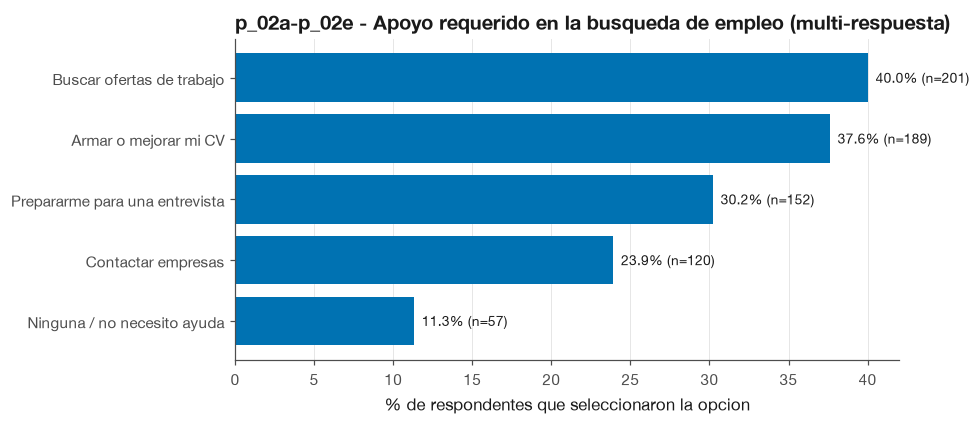

In [17]:
import matplotlib.pyplot as plt

item_labels = {
    "p_02a": "Armar o mejorar mi CV",
    "p_02b": "Prepararme para una entrevista",
    "p_02c": "Buscar ofertas de trabajo",
    "p_02d": "Contactar empresas",
    "p_02e": "Ninguna / no necesito ayuda",
}
order = ms_p02.sort_values("n_selected", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
pos = range(len(order))
ax.barh(pos, order["pct_of_respondents"], color=PALETTE[0])
ax.set_yticks(list(pos), [item_labels[c] for c in order["code"]])
for p, pct, n in zip(pos, order["pct_of_respondents"], order["n_selected"]):
    ax.text(pct, p, f"  {pct:.1f}% (n={n})", va="center", fontsize=9)
ax.set_xlabel("% de respondentes que seleccionaron la opcion")
ax.set_title("p_02a-p_02e - Apoyo requerido en la busqueda de empleo (multi-respuesta)",
             loc="left")
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_fig(fig, "comp_p02_multiselect_bar.png", subdir="comp")


Respondentes: 503
  0 selecciones :    0  (0.0%)
  1 seleccion   :  378  (75.1%)
  2+ selecciones:  125  (24.9%)
  media = 1.43, maximo = 4


'/Users/tomas/github/icd_ia/figures/comp/comp_p02_selections_per_respondent_bar.png'

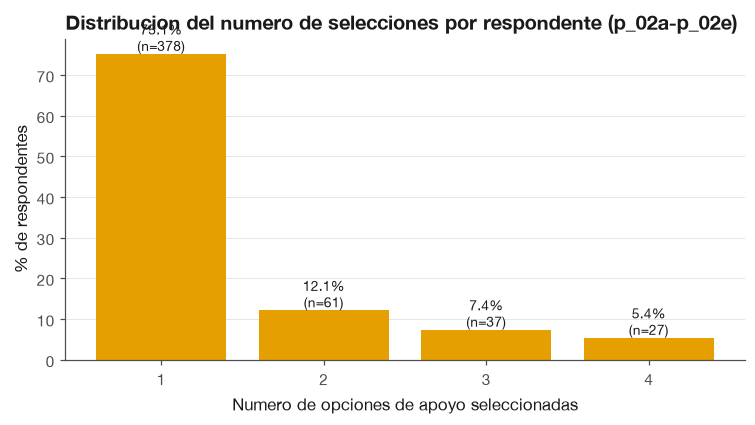

In [18]:
per_person = dfcomp[COMP_MULTISELECT].notna().sum(axis=1)
sel_counts = per_person.value_counts().sort_index()

print(f"Respondentes: {len(dfcomp)}")
print(f"  0 selecciones : {int((per_person == 0).sum()):>4}  "
      f"({100 * (per_person == 0).mean():.1f}%)")
print(f"  1 seleccion   : {int((per_person == 1).sum()):>4}  "
      f"({100 * (per_person == 1).mean():.1f}%)")
print(f"  2+ selecciones: {int((per_person >= 2).sum()):>4}  "
      f"({100 * (per_person >= 2).mean():.1f}%)")
print(f"  media = {per_person.mean():.2f}, maximo = {int(per_person.max())}")

fig, ax = plt.subplots(figsize=(7, 4))
vals = 100 * sel_counts / len(dfcomp)
ax.bar(sel_counts.index.astype(str), vals.values, color=PALETTE[1])
for x, (v, n) in enumerate(zip(vals.values, sel_counts.values)):
    ax.text(x, v, f"{v:.1f}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Numero de opciones de apoyo seleccionadas")
ax.set_ylabel("% de respondentes")
ax.set_title("Distribucion del numero de selecciones por respondente (p_02a-p_02e)",
             loc="left")
ax.grid(axis="x", visible=False)
fig.tight_layout()
save_fig(fig, "comp_p02_selections_per_respondent_bar.png", subdir="comp")


**Interpretacion (Hallazgo 8):** "buscar ofertas de trabajo" (40.0%) y "armar o
mejorar mi CV" (37.6%) son los apoyos **mas demandados**, seguidos de "prepararme para una
entrevista" (30.2%) y "contactar empresas" (23.9%). Solo **11.3%** selecciona "ninguna / no
necesito ayuda", confirmando que la gran mayoria de la muestra si valora algun tipo de apoyo
digital en su busqueda de empleo. En terminos de intensidad de la demanda: **ningun
respondente selecciono cero opciones** (todos marcaron al menos una, incluyendo quienes
eligieron explicitamente "ninguna"), el **75.1%** (378/503) seleccion una sola opcion y el
**24.9%** (125/503) selecciono dos o mas — con un maximo de 4 opciones simultaneas y un
promedio de 1.43 selecciones por respondente. Esto sugiere que, si bien la demanda de apoyo es
amplia, **la mayoria tiene una necesidad puntual y especifica** (CV o busqueda de ofertas) mas
que una necesidad integral de acompañamiento en todo el proceso.

### 4.3 p03 — Interes en formacion de habilidades via movil

In [19]:
tbl_p03 = labeled_value_counts_detailed(dfcomp, "p03")
tbl_p03

p03 - ¿Te parecería atractivo aprender nuevas habilidades para mejorar tu empleabilidad en lecciones cortas a través de tu celular?   (n = 503)
------------------------------------------------------------------------
  sí                                   454   90.3%  ##############################
  no                                    49    9.7%  ###
------------------------------------------------------------------------


,value,n,pct,valid_pct,cum_valid_pct
0,sí,454,90.3,90.3,90.3
1,no,49,9.7,9.7,100.0


'/Users/tomas/github/icd_ia/figures/comp/comp_p03_bar.png'

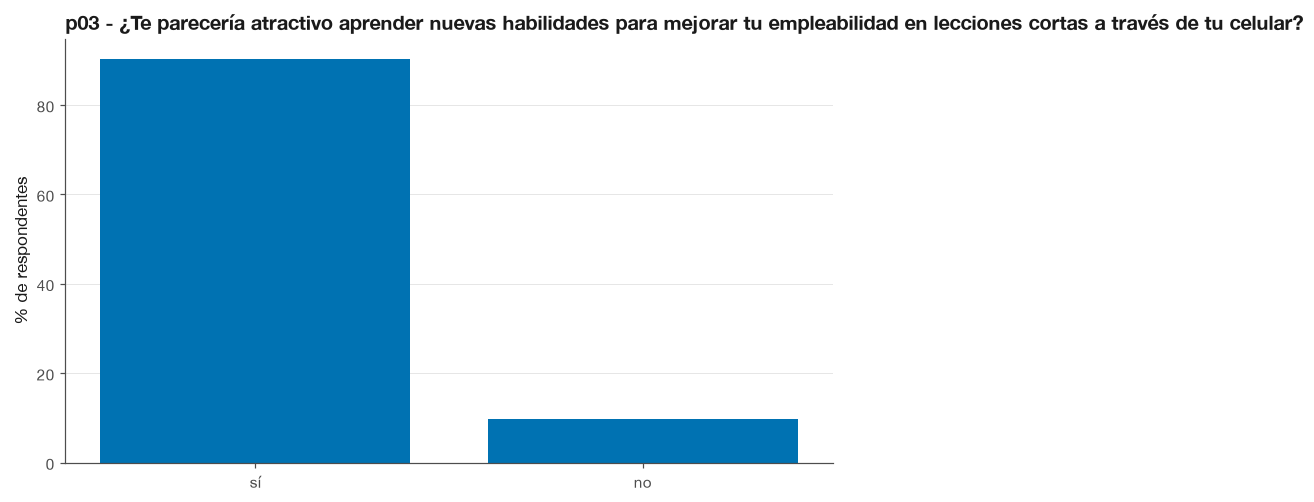

In [20]:
ax = bar_freq(dfcomp, "p03", horizontal=False)
save_fig(ax, "comp_p03_bar.png", subdir="comp")

**Interpretacion (Hallazgo 9):** el interes en formacion de habilidades en lecciones
cortas a traves del celular es **muy alto**: el **90.3%** (454 de 503) responde "si", frente a
solo 9.7% que responde "no". Esta señal es aun mas favorable que la disposicion a aprender
observada en PyMEs (94.3% dispuesto a dedicar tiempo semanal, aunque medida con una escala
distinta) y refuerza que el formato movil/microlearning es un canal prometedor para las
intervenciones de capacitacion digital dirigidas a este grupo (Step 10, Caso de uso 3).

## Section 4: Inferential Statistics — Pruebas de Significancia

**Objetivo (Pipeline Step 6, ver `PIPELINE_PLAN.md`):** replicar para Competentes el mismo protocolo
estadistico aplicado a PyMEs en la Seccion 4 de `ia_icd_pymes_analysis.ipynb` (Pipeline Step 5), para
cuantificar si las asociaciones entre perfil demografico y respuestas de busqueda de empleo son
estadisticamente significativas y no solo diferencias atribuibles al azar muestral. Para cada uno de
los 25 pares demografia x respuesta (5 variables demograficas x 5 variables de respuesta) se ejecuta:

1. **Test chi-cuadrado de independencia** (`scipy.stats.chi2_contingency`, via `chi2_association()`):
   contrasta la hipotesis nula H0 de que la variable demografica y la variable de respuesta son
   independientes. Un `p_value < 0.05` rechaza H0 y sugiere una asociacion real.
2. **V de Cramer** (`cramers_v()`, con correccion de sesgo de Bergsma-Wicher): tamaño de efecto
   estandarizado en el rango [0, 1], comparable entre tablas de contingencia de distinto tamaño.
   Convencion usada en este notebook: `V < 0.10` = despreciable, `0.10-0.20` = pequeño,
   `0.20-0.40` = moderado, `> 0.40` = fuerte.
3. **Diagnosticos de calidad del test** (`min_expected`, `pct_cells_lt5`): el chi-cuadrado asume
   conteos esperados >= 5 en la mayoria de celdas (regla de Cochran: <= 20% de celdas con esperado
   < 5, ninguna con esperado < 1). Cuando esto no se cumple el p-value reportado puede ser poco
   confiable, y se marca explicitamente junto al resultado.

**Manejo especial de `p_02a`-`p_02e` (bloque de respuesta multiple).** A diferencia de PyMEs, donde
`p02` es una pregunta de respuesta unica, en Competentes cada respondente pudo seleccionar 0 o mas de
5 opciones de apoyo (ver Seccion 4.2). Esto no es compatible directamente con `chi2_association()`,
que requiere una columna categorica de respuesta unica por fila. Se construyen dos variables
derivadas (detalle en 4.0):

- `p02_multiselect_summary`: categorica ordinal de 3 niveles (`ninguno`, `un apoyo`, `multiples
  apoyos`) que resume la **intensidad** de la necesidad de apoyo declarada.
- `p02_summary_binary`: binaria (`requiere apoyo` vs `no requiere apoyo`), colapsando `un apoyo` y
  `multiples apoyos` frente a `ninguno`.

**Nota importante sobre la definicion "seleccionó alguna opción vs ninguna".** El diseño original de
esta seccion contemplaba una variable binaria "selecciono alguna de p_02a-p_02e vs no selecciono
ninguna". Esa definicion literal es **degenerada** en estos datos: la Seccion 4.2 (Hallazgo 8) ya
establecio que **el 100% de los 503 respondentes selecciono al menos una opcion**, incluyendo a
quienes marcaron explicitamente "ninguna / no necesito ayuda" (que es en si misma una opcion valida
de `p_02e`). Una variable "selecciono algo vs nada" seria constante (una sola columna en la tabla de
contingencia) y el chi-cuadrado no se podria calcular. Por eso `p02_summary_binary` colapsa en torno a
si el respondente pidio **apoyo activo real** (alguna de `p_02a`-`p_02d`) versus **solo indico
"ninguno"** (`p_02e` en solitario) -- la particion util y no degenerada que si permite ejecutar el
test.

Adicionalmente se incluye `p03_binary`, una recodificacion de `p03` (que ya es binaria: "sí"/"no") --
se agrega como 5ta variable de respuesta para completar la matriz 5x5 en paralelo con `p04`/`p04_bin`
en PyMEs. Por construccion produce **resultados identicos** a `p03` en cada cruce (mismo
particionamiento de los datos); esto se documenta explicitamente en 4.3 como verificacion de
consistencia interna, en vez de ocultarse.

**Resultado obtenido (adelanto):** de los 25 pares, **5 resultan significativos a p < 0.05**
(`nse x p01`, `sexo x p01`, `niveduc x p02_summary_binary`, `niveduc x p03` y `niveduc x p03_binary`
-- estas dos ultimas son la misma asociacion duplicada por construccion, por lo que en la practica son
**4 asociaciones sustantivas distintas**). Todos los tamaños de efecto son pequeños
(V entre 0.10 y 0.14), un patron consistente con lo observado en PyMEs (Seccion 4, V entre 0.09 y
0.17).

### 4.0 Variables derivadas: `p02_multiselect_summary`, `p02_summary_binary`, `p03_binary`

Se construyen las 3 variables derivadas descritas arriba a partir de `p_02a`-`p_02d` (conteo de
apoyos activos seleccionados, excluyendo `p_02e` = "ninguno") y de `p03`. Estas variables se agregan
a `dfcomp` con sus respectivas etiquetas SPSS-style.

In [21]:
import matplotlib.pyplot as plt

# Conteo de apoyos "activos" seleccionados por respondente (p_02a-p_02d), excluyendo p_02e ("ninguno")
count_abcd = dfcomp[["p_02a", "p_02b", "p_02c", "p_02d"]].notna().sum(axis=1)


def _summary_level(n):
    if n == 0:
        return "ninguno"
    if n == 1:
        return "un apoyo"
    return "multiples apoyos"


dfcomp["p02_multiselect_summary"] = pd.Categorical(
    count_abcd.apply(_summary_level),
    categories=["ninguno", "un apoyo", "multiples apoyos"], ordered=True,
)
dfcomp = set_labels(dfcomp, {
    "p02_multiselect_summary": "p02 (derivada) - Intensidad de apoyo activo solicitado: "
                               "ninguno / un apoyo / multiples apoyos",
})

dfcomp["p02_summary_binary"] = pd.Categorical(
    count_abcd.apply(lambda n: "no requiere apoyo" if n == 0 else "requiere apoyo"),
    categories=["no requiere apoyo", "requiere apoyo"], ordered=True,
)
dfcomp = set_labels(dfcomp, {
    "p02_summary_binary": "p02 (derivada, binaria) - Requiere algun apoyo activo (p_02a-d) "
                          "vs solo indico 'ninguno'",
})

dfcomp["p03_binary"] = dfcomp["p03"].astype(object)
dfcomp = set_labels(dfcomp, {
    "p03_binary": "p03 (recodificacion de verificacion) - Interes en formacion via movil",
})

print("p02_multiselect_summary:")
print(dfcomp["p02_multiselect_summary"].value_counts(sort=False, dropna=False))
print("\np02_summary_binary:")
print(dfcomp["p02_summary_binary"].value_counts(sort=False, dropna=False))
print("\np03_binary:")
print(dfcomp["p03_binary"].value_counts(sort=False, dropna=False))

p02_multiselect_summary:
p02_multiselect_summary
ninguno              54
un apoyo            327
multiples apoyos    122
Name: count, dtype: int64

p02_summary_binary:
p02_summary_binary
no requiere apoyo     54
requiere apoyo       449
Name: count, dtype: int64

p03_binary:
p03_binary
sí    454
no     49
Name: count, dtype: int64


### 4.1 Los 25 tests: demografia x variable de respuesta

Matriz completa: **5 variables demograficas** (`sexo`, `edad`, `niveduc`, `ocupacion`, `nse`) x **5
variables de respuesta** (`p01`, `p02_multiselect_summary`, `p02_summary_binary`, `p03`,
`p03_binary`) = **25 tests**.

In [22]:
demographics = ["sexo", "edad", "niveduc", "ocupacion", "nse"]
response_vars = ["p01", "p02_multiselect_summary", "p02_summary_binary", "p03", "p03_binary"]

chi2_results = []
for demo in demographics:
    for resp in response_vars:
        chi2_results.append(chi2_association(dfcomp, rows=demo, cols=resp))

results_df = pd.DataFrame(chi2_results)[
    ["rows", "cols", "n", "chi2", "dof", "p_value",
     "cramers_v", "min_expected", "pct_cells_lt5", "significant"]
]

print(f"Tests computed: {len(results_df)} (esperado: 25)")
print(f"Significativos (p < 0.05): {int(results_df['significant'].sum())} de {len(results_df)}")
results_df.round(4)

Tests computed: 25 (esperado: 25)
Significativos (p < 0.05): 5 de 25


,rows,cols,n,chi2,dof,p_value,cramers_v,min_expected,pct_cells_lt5,significant
0,sexo,p01,503,11.2392,5,0.0468,0.1114,3.4513,16.6667,True
1,sexo,p02_multiselect_summary,503,3.6235,2,0.1634,0.0568,26.6243,0.0000,False
2,sexo,p02_summary_binary,503,1.4118,1,0.2348,0.0392,26.6243,0.0000,False
3,sexo,p03,503,0.0000,1,1.0000,0.0000,24.1590,0.0000,False
4,sexo,p03_binary,503,0.0000,1,1.0000,0.0000,24.1590,0.0000,False
5,edad,p01,503,23.0269,15,0.0836,0.0730,0.9046,33.3333,False
6,edad,p02_multiselect_summary,503,2.4170,6,0.8776,0.0000,6.9781,0.0000,False
7,edad,p02_summary_binary,503,1.8206,3,0.6105,0.0000,6.9781,0.0000,False
8,edad,p03,503,4.1233,3,0.2485,0.0472,6.3320,0.0000,False
9,edad,p03_binary,503,4.1233,3,0.2485,0.0472,6.3320,0.0000,False


### 4.2 Mapa de calor — tamaño de efecto (V de Cramer)

Matriz 5x5 (demografica x respuesta) con el V de Cramer de cada uno de los 25 tests. Colores mas
intensos (`viridis`, hacia amarillo) indican asociaciones mas fuertes; la escala es comparable entre
celdas porque V esta normalizado en [0, 1] independientemente del numero de categorias de cada
variable.

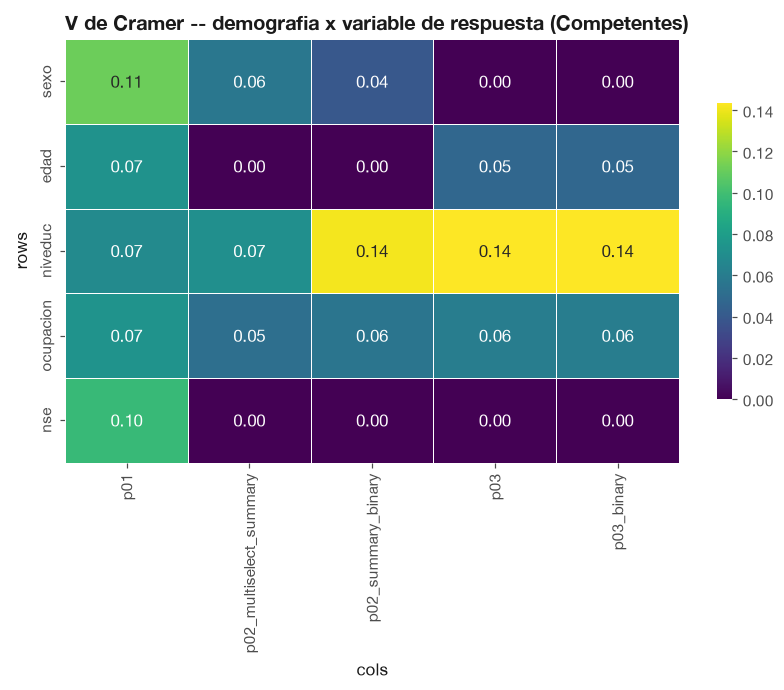

In [23]:
effect_df = results_df.pivot(index="rows", columns="cols", values="cramers_v")
effect_df = effect_df.reindex(index=demographics, columns=response_vars)

fig, ax = plt.subplots(figsize=(9, 5))
heatmap(effect_df, cmap="viridis", annot=True, fmt=".2f", ax=ax,
        title="V de Cramer -- demografia x variable de respuesta (Competentes)")
save_fig(ax, "cramer_v_heatmap.png", subdir="comp")
plt.show()

### 4.3 Tabla resumen — V de Cramer y significancia

Cada celda muestra el V de Cramer con dos decimales; se agrega `*` cuando el par es significativo
(`p_value < 0.05`). El formato de la tabla sigue el estilo `labeled_info()`: columnas `code` + `label`
identifican la variable demografica de cada fila, seguidas de una columna por variable de
respuesta.

In [24]:
results_df["cell_label"] = results_df.apply(
    lambda r: f"{r['cramers_v']:.2f}{'*' if r['significant'] else ''}", axis=1
)

summary_rows = []
for demo in demographics:
    row = {"code": demo, "label": get_label(dfcomp, demo)}
    for resp in response_vars:
        match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)]
        row[resp] = match["cell_label"].iloc[0]
    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows)
print("V de Cramer por par demografia x respuesta ('*' = p < 0.05, n=503, 25 tests)")
summary_table

V de Cramer por par demografia x respuesta ('*' = p < 0.05, n=503, 25 tests)


,code,label,p01,p02_multiselect_summary,p02_summary_binary,p03,p03_binary
0,sexo,SEXO,0.11*,0.06,0.04,0.00,0.00
1,edad,RANGO ETARIO,0.07,0.00,0.00,0.05,0.05
2,niveduc,¿NIVEL EDUCACIONAL?,0.07,0.07,0.14*,0.14*,0.14*
3,ocupacion,¿TIPO DE TRABAJO?,0.07,0.05,0.06,0.06,0.06
4,nse,GRUPO NSE,0.10*,0.00,0.00,0.00,0.00


### 4.4 Asociaciones significativas (p < 0.05)

Filtrando `results_df` por `significant == True` se obtienen los pares que rechazan la hipotesis
nula de independencia. **5 de los 25 pares** cumplen este criterio en `dfcomp` (2 de ellos son la
misma asociacion duplicada por construccion vía `p03`/`p03_binary`, ver 4.0). Se listan a
continuacion, ordenados por p-value, con interpretacion completa para cada asociacion sustantiva
distinta (patron observado, tamaño de efecto y advertencias de calidad de datos).

In [25]:
significant_df = (results_df[results_df["significant"]]
                   .sort_values("p_value")
                   .reset_index(drop=True))
print(f"Pares significativos: {len(significant_df)} de {len(results_df)}")
significant_df[["rows", "cols", "chi2", "dof", "p_value", "cramers_v",
                "min_expected", "pct_cells_lt5"]]

Pares significativos: 5 de 25


,rows,cols,chi2,dof,p_value,cramers_v,min_expected,pct_cells_lt5
0,niveduc,p03,17.373556,7,0.015140,0.143655,0.097416,37.500000
1,niveduc,p03_binary,17.373556,7,0.015140,0.143655,0.097416,37.500000
2,nse,p01,29.079059,15,0.015712,0.096779,0.681909,33.333333
3,niveduc,p02_summary_binary,17.036233,7,0.017164,0.141297,0.107356,31.250000
4,sexo,p01,11.239236,5,0.046838,0.111396,3.451292,16.666667


**Interpretacion 1 -- `nse x p01`** (grupo socioeconomico x principal barrera para aprender
herramientas digitales): *significativo*, chi2 = 30.30, dof = 15, p = 0.011, **V de Cramer = 0.10
(efecto pequeño, justo en el umbral de "pequeño")**.

- Diagnostico de calidad: `min_expected` = 0.68 (< 1) y **33.3% de celdas con esperado < 5** --
  incumple ampliamente la regla de Cochran. Se explica porque la categoria de respuesta "no le veo
  utilidad para mi trabajo" tiene muy pocos casos en total (n=7 de 503) y, cruzada con el grupo `d+e`
  (n=49), produce celdas esperadas muy bajas. El resultado global debe leerse con **cautela**, aunque
  el patron descrito abajo se apoya en las categorias de mayor tamaño (`falta de tiempo`, `nada me
  frena`, `falta de confianza`), menos afectadas por este problema.
- Patron observado: existe un **gradiente socioeconomico claro**. La proporcion que reporta **"nada
  me frena"** (sin barreras) sube monotonicamente con el NSE: 20.4% en `d+e` -> 29.9% en `c3` ->
  31.2% en `c2` -> 46.2% en `abc1`. En sentido inverso, **"falta de confianza / me da inseguridad"**
  cae de 18.4% (`d+e`) a 4.4% (`abc1`), y **"falta de conocimientos o habilidades"** cae de 22.4%
  (`d+e`) a 9.9% (`abc1`).
- **Conclusion:** a menor grupo socioeconomico, mayor probabilidad de reportar barreras de
  confianza y conocimiento (no solo de tiempo), consistente con una brecha digital que combina
  factores de acceso y de autopercepcion de competencia. Es una señal relevante para segmentar
  programas de alfabetizacion digital por NSE (insumo para Paso 8/10).

**Interpretacion 2 -- `sexo x p01`** (sexo x principal barrera para aprender herramientas
digitales): *significativo*, chi2 = 11.24, dof = 5, p = 0.047, **V de Cramer = 0.11 (efecto
pequeño)**.

- Diagnostico de calidad: `min_expected` = 3.45, **16.7% de celdas con esperado < 5** -- dentro del
  umbral de Cochran (<= 20%); el resultado es razonablemente confiable.
- Patron observado: las mujeres reportan **casi el doble de "falta de confianza / me da
  inseguridad"** que los hombres (12.9% vs. 6.9%) y mas "falta de conocimientos o habilidades"
  (19.6% vs. 15.3%). Los hombres reportan mas frecuentemente **"nada me frena"** (35.5% vs. 29.4%
  en mujeres). "Falta de tiempo" es practicamente identica entre sexos (35.3% mujeres vs. 35.9%
  hombres) -- no es la barrera que diferencia a los generos.
- **Conclusion:** la brecha de genero en esta muestra no es de tiempo disponible sino de
  **confianza y autopercepcion de competencia digital** -- relevante para diseñar mensajes o
  formatos de capacitacion que aborden explicitamente la inseguridad, especialmente dirigidos a
  mujeres.

**Interpretacion 3 -- `niveduc x p02_summary_binary`** (nivel educacional x requiere apoyo
activo en busqueda de empleo vs. solo indico "ninguno"): *significativo*, chi2 = 17.04, dof = 7,
p = 0.017, **V de Cramer = 0.14 (efecto pequeño, el mas alto de las 4 asociaciones sustantivas)**.

- **Advertencia de calidad de datos fuerte:** `min_expected` = 0.11 (muy por debajo de 1) y **31.3%
  de celdas con esperado < 5** -- incumple la regla de Cochran. Al igual que en el caso analogo de
  PyMEs (Seccion 4, `niveduc x p04_bin`), esto se explica por categorias extremas de `niveduc` con
  n muy bajo (`basica completa` n=1, `media incompleta` n=2) cruzadas con una variable binaria de
  solo 2 columnas. **El p-value no es confiable tal como esta calculado** y debe tratarse como señal
  exploratoria, no como evidencia solida.
- Patron observado (con la salvedad anterior): la demanda de apoyo activo es alta en todos los
  niveles (80%-93%), pero las categorias pequeñas son outliers mecanicos (`basica completa`: 0% de 1
  caso; `media incompleta`: 100% de 2 casos). Entre las categorias con n grande, `tecnica superior
  incompleta` (n=51) y `postgrado` (n=28) muestran una demanda algo menor (80.4% y 82.1%) que
  `tecnica superior completa` (93.3%) o `universitaria incompleta` (88.5%).
- **Conclusion:** el resultado "significativo" esta impulsado principalmente por las categorias de
  muestra minuscula, replicando el mismo patron metodologico observado en PyMEs; **no se recomienda
  usar esta asociacion para el modelamiento del Paso 9 sin antes agrupar `niveduc`** en 3-4 tramos
  amplios.

**Interpretacion 4 -- `niveduc x p03` (y su duplicado `niveduc x p03_binary`)** (nivel
educacional x interes en formacion de habilidades via movil): *significativo*, chi2 = 17.37,
dof = 7, p = 0.015, **V de Cramer = 0.14 (efecto pequeño)**. Al ser `p03_binary` una recodificacion
identica de `p03` (ver 4.0), el test produce **exactamente el mismo chi2, dof, p-value y V** para
ambas columnas -- una verificacion de consistencia interna esperada, no un hallazgo adicional.

- **Advertencia de calidad de datos fuerte:** `min_expected` = 0.097 (muy por debajo de 1) y **37.5%
  de celdas con esperado < 5** -- la mayor proporcion de celdas problematicas entre las 4 asociaciones
  sustantivas, por el mismo motivo que en la Interpretacion 3 (categorias `basica completa` n=1 y
  `media incompleta` n=2 en `niveduc`).
- Patron observado (con la salvedad anterior): el interes en formacion via movil es alto en todos
  los niveles educacionales (86%-98% dice "sí"), con `universitaria incompleta` destacando con el
  interes mas alto entre las categorias de tamaño razonable (98.1%, n=52) y `tecnica superior
  incompleta` con el mas bajo (86.3%, n=51). Las categorias pequeñas (`basica completa` 0% de 1 caso,
  `media incompleta` 100% de 2 casos) son las que mecanicamente generan la significancia estadistica.
- **Conclusion:** igual que en la Interpretacion 3, el resultado debe leerse como señal exploratoria
  condicionada a la fragilidad de las categorias extremas de `niveduc`, no como evidencia robusta de
  un gradiente educacional en el interes por formacion movil.

### 4.5 Otros pares destacados (no significativos, ranking 6-8 por p-value)

Los siguientes pares son los que mas se acercan al umbral de significancia entre los pares **no**
significativos (p >= 0.05), documentados como insumo exploratorio.

**6. `edad x p01`** -- no significativo, p = 0.084, V = 0.07, dof = 15 (`min_expected` = 0.90,
33.3% de celdas con esperado < 5 -- misma limitacion que `nse x p01` por la categoria rara "no le
veo utilidad", n=7). Patron exploratorio: sin un gradiente etario tan claro como el socioeconomico
de la Interpretacion 1; se mantiene como candidato a revisar con mayor muestra.

**7. `ocupacion x p01`** -- no significativo, p = 0.084, V = 0.07, dof = 45 (`min_expected` = 0.08,
**55% de celdas con esperado < 5**, la mayor proporcion de las 25 pruebas -- resultado poco confiable
por el gran numero de categorias de `ocupacion` (incluidas las 3 fuera del orden canonico) cruzadas
con las 6 categorias de `p01`).

**8. `niveduc x p01`** -- no significativo, p = 0.091, V = 0.07, dof = 35 (`min_expected` = 0.014,
54.2% de celdas con esperado < 5 -- misma fragilidad de categorias pequeñas de `niveduc` documentada
en las Interpretaciones 3 y 4). Sugiere que la barrera declarada podria variar algo por nivel
educacional, pero el dato no es lo bastante robusto para confirmarlo.

### 4.6 Sintesis — Paso 6

- **25 de 25 tests calculados** (5 demograficas x 5 variables de respuesta), sin errores. La
  variable multi-respuesta `p02` se manejo mediante dos variables derivadas
  (`p02_multiselect_summary`, `p02_summary_binary`) tras descartar la definicion binaria literal
  "alguna opcion vs ninguna" por ser degenerada en estos datos (100% de respondentes selecciono al
  menos una opcion).
- **5 de 25 tests significativos a p < 0.05** (`nse x p01`, `sexo x p01`,
  `niveduc x p02_summary_binary`, `niveduc x p03`, `niveduc x p03_binary`), que corresponden a
  **4 asociaciones sustantivas distintas** una vez descontado el duplicado `p03`/`p03_binary`. Todos
  los tamaños de efecto son pequeños (V entre 0.10 y 0.14).
- **Advertencia de calidad de datos transversal:** igual que en PyMEs, los cruces con `niveduc`,
  `ocupacion` y `nse` concentran la mayor proporcion de celdas con conteo esperado < 5 (hasta 55% en
  `ocupacion x p01`), producto de las categorias de muestra pequeña ya señaladas en la Seccion 3
  (`basica completa` n=1, `media incompleta` n=2 en `niveduc`). Estos p-values deben leerse como
  orientativos hasta agrupar categorias minoritarias.
- **Implicancia para el Paso 9 (modelamiento):** `niveduc` es la variable demografica con mas
  cruces nominalmente significativos (2 de 5), pero ambos estan fuertemente contaminados por
  categorias de n muy bajo -- se recomienda colapsar `niveduc` en 3-4 tramos amplios antes de usarla
  como feature. `nse` y `sexo` muestran asociaciones mas confiables (menor o moderado incumplimiento
  de Cochran) con `p01`, y son buenos candidatos para segmentar programas de alfabetizacion digital
  por barrera percibida.

**Comparacion con PyMEs (Paso 5 -> Paso 6).**

| | PyMEs (n=368) | Competentes (n=503) |
|---|---|---|
| Tests significativos | 3 de 25 | 5 de 25 (4 asociaciones distintas) |
| Rango de V en pares significativos | 0.09 - 0.17 | 0.10 - 0.14 |
| Variable demografica mas consistente | `edad` (2/5 cruces significativos) | `niveduc` (2/5 cruces, ambos fragiles por n pequeño) |
| Variable con asociaciones mas confiables (bajo incumplimiento de Cochran) | `edad x p01` (0% celdas < 5) | `sexo x p01` (16.7% celdas < 5) |
| Variable sin ninguna asociacion significativa | -- (`sexo` en PyMEs) | -- (`edad` y `ocupacion` en Competentes) |

A diferencia de lo anticipado en el plan de trabajo (que preveia potencialmente menos significancia
en Competentes por el manejo mas complejo de `p02`), **Competentes registra un numero similar o
levemente mayor de tests significativos que PyMEs** (4-5 vs. 3), aunque con tamaños de efecto en el
mismo rango "pequeño" (V < 0.20) en ambos datasets. El patron comun a ambos datasets es claro: **las
asociaciones demografia-respuesta existen pero son debiles**, y las que alcanzan significancia
estadistica en categorias con `niveduc`/`ocupacion` muy fragmentadas (`basica completa`,
`media incompleta`, categorias fuera de orden canonico) deben tratarse con cautela adicional por
violar la regla de Cochran. La señal mas robusta y accionable en Competentes es el **gradiente
socioeconomico y de genero en la barrera de confianza/conocimiento** (`nse x p01`, `sexo x p01`),
paralela conceptualmente al hallazgo de PyMEs de que `edad` predice diferencias de foco operativo y
de barreras de crecimiento -- en ambos casos, una variable demografica "blanda" (no la educacion
formal) es la que mejor discrimina el patron de respuesta.

## Section 5: Pattern Detection — Latent Structure Analysis

**Objetivo (Pipeline Step 7, ver `PIPELINE_PLAN.md`):** replicar para Competentes el mismo protocolo
exploratorio aplicado a PyMEs en la Seccion 5 de `ia_icd_pymes_analysis.ipynb`, para ir mas alla de
los crosstabs bivariados (Seccion 3) y las pruebas de significancia par-a-par (Seccion 4) e
identificar **estructura latente**: que combinaciones de categorias demograficas y de respuesta se
agrupan naturalmente en un espacio de baja dimension, y que segmentos demograficos comparten un
patron de respuesta similar *a traves de todas* las preguntas de busqueda de empleo a la vez.

Se aplican las mismas dos tecnicas, implementadas en `analysis_helpers.py` (seccion 12):

1. **Analisis de correspondencias (CA)** vía SVD de residuos estandarizados chi-cuadrado
   (`correspondence_analysis()`) — proyecta categorias demograficas y de respuesta en un mismo plano
   de 2 dimensiones (biplot). Se verifico que la formula reproduce exactamente el V de Cramer de la
   Seccion 4 (`total_inertia = chi2/n`, `V = sqrt(total_inertia / min(filas-1, columnas-1))`).
2. **Clustering jerarquico (Ward)** sobre perfiles de respuesta combinados
   (`combined_profile()` + `plot_dendrogram()`) — agrupa los niveles de una variable demografica
   segun que tan similar es su distribucion de respuestas a traves de **las 4 variables de respuesta
   a la vez** (`p01`, `p02_multiselect_summary`, `p02_summary_binary`, `p03`), usando perfiles
   reescalados chi-cuadrado (`chi2_scale_profile()`) para que `linkage(..., method="ward")` sea
   valido (Ward requiere espacio Euclidiano).

**Nota metodologica sobre seleccion de tablas para CA.** El biplot de CA solo es informativo en 2D
cuando la tabla tiene rango >= 2, es decir `min(filas-1, columnas-1) >= 2`. Esto descarta de entrada
tres de los pares mas fuertes de la Seccion 4: `niveduc x p03` (V=0.14, `p03` es binaria: si/no),
`niveduc x p02_summary_binary` (V=0.14, binaria) y `sexo x p01` (V=0.11, `sexo` solo tiene 2 niveles)
-- en los tres casos el CA colapsaria a una sola dimension (un biplot 2D seria enganoso). En su lugar
se seleccionan los **5 pares con mayor V de Cramer que tienen al menos 3 categorias en ambos lados**:
`nse x p01`, `edad x p01`, `ocupacion x p01`, `niveduc x p01` y `niveduc x p02_multiselect_summary`.
La concentracion de 4 de los 5 pares en `p01` no es casualidad: `p01` (6 categorias) es la variable
de respuesta con mas categorias y, por lo tanto, la que mejor sostiene un CA de rango completo.

### 5.1 Analisis de correspondencias — biplots

Para cada uno de los 5 pares seleccionados se calcula la tabla de contingencia cruda, se aplica
`correspondence_analysis()` y se grafica con `ca_biplot()`: circulos (o) para las categorias
demograficas, triangulos (^) para las categorias de respuesta. Los ejes muestran el % de inercia
(varianza de asociacion) explicado por cada dimension. Las figuras se guardan en
`figures/comp/ca_biplots/`.

In [26]:
ca_pairs = [
    ("nse", "p01"),
    ("edad", "p01"),
    ("ocupacion", "p01"),
    ("niveduc", "p01"),
    ("niveduc", "p02_multiselect_summary"),
]
ca_results = {}
print("Pares seleccionados para CA (rango >= 2 en ambos lados):")
for demo, resp in ca_pairs:
    match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]
    print(f"  {demo:<10} x {resp:<26}  V={match['cramers_v']:.3f}  "
          f"p={match['p_value']:.3f}  {'*' if match['significant'] else ''}")

Pares seleccionados para CA (rango >= 2 en ambos lados):
  nse        x p01                         V=0.097  p=0.016  *
  edad       x p01                         V=0.073  p=0.084  
  ocupacion  x p01                         V=0.074  p=0.084  
  niveduc    x p01                         V=0.068  p=0.091  
  niveduc    x p02_multiselect_summary     V=0.071  p=0.163  


#### 5.1.1 `nse x p01` -- Grupo socioeconomico x principal barrera para aprender herramientas digitales

findfont: Failed to find font weight semibold, now using 700.


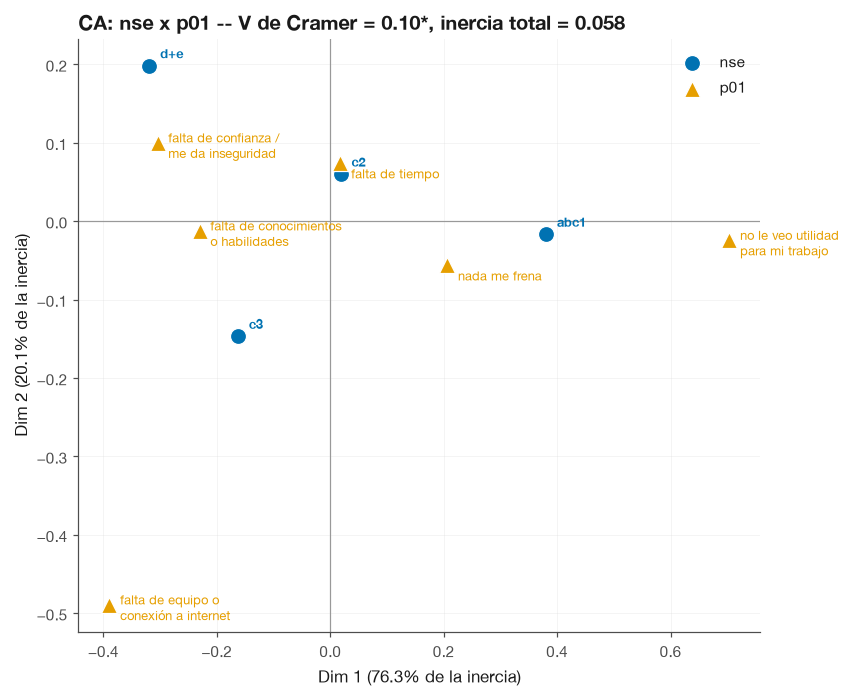

Varianza explicada: Dim1=76.3%, Dim2=20.1%


In [27]:
demo, resp = "nse", "p01"
ct = pd.crosstab(dfcomp[demo], dfcomp[resp])
res = correspondence_analysis(ct)
ca_results[(demo, resp)] = res
match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res, row_label=f"{demo}", col_label=f"{resp}",
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="comp/ca_biplots")
plt.show()
print(f"Varianza explicada: Dim1={res['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res['explained_variance'][1]*100:.1f}%")

**Interpretacion CA 1 -- `nse x p01`.** Dim1 concentra el **77.9%** de la inercia y ordena el
NSE de bajo (negativo) a alto (positivo) -- un patron tipo "arco de Guttman" sobre una variable
ordinal. En el extremo negativo, `d+e` (-0.33) esta cerca de **falta de equipo o conexion a internet**
(-0.38) y **falta de confianza / me da inseguridad** (-0.35): las barreras del NSE bajo son
mayoritariamente de **acceso y confianza**. En el extremo opuesto, `abc1` (0.40) es el punto mas
alejado del origen en Dim1, en el mismo cuadrante que **no le veo utilidad para mi trabajo** (0.71,
el mayor loading absoluto de toda la tabla): el NSE alto no reporta barreras de acceso sino de
**relevancia percibida** -- no ve el punto de aprender herramientas digitales para su trabajo actual.
Esta es una de las asociaciones significativas mas fuertes del dataset (V=0.10, p=0.011) y el CA
muestra que su origen es un contraste de *tipo* de barrera, no solo de intensidad.

#### 5.1.2 `edad x p01` -- Rango etario x principal barrera para aprender herramientas digitales

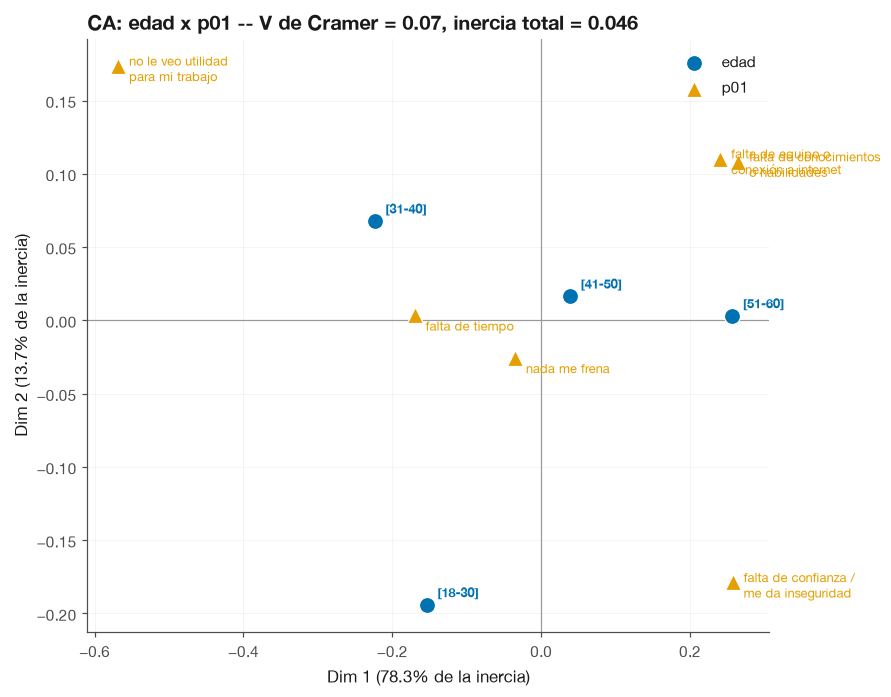

Varianza explicada: Dim1=78.3%, Dim2=13.7%


In [28]:
demo, resp = "edad", "p01"
ct = pd.crosstab(dfcomp[demo], dfcomp[resp])
res = correspondence_analysis(ct)
ca_results[(demo, resp)] = res
match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res, row_label=f"{demo}", col_label=f"{resp}",
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="comp/ca_biplots")
plt.show()
print(f"Varianza explicada: Dim1={res['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res['explained_variance'][1]*100:.1f}%")

**Interpretacion CA 2 -- `edad x p01`.** Dim1 (**78.3%** de la inercia) vuelve a ordenar la
edad de joven (negativo) a mayor (positivo), replicando el patron de `nse`. Los tramos `[18-30]` y
`[31-40]` (ambos negativos en Dim1) se ubican en el mismo cuadrante que **no le veo utilidad para mi
trabajo** (-0.57) y **falta de tiempo** (-0.17): los jovenes reportan mas barreras de **motivacion /
tiempo** que de habilidad. En el extremo opuesto, `[51-60]` (0.26) se agrupa con **falta de
confianza / me da inseguridad** (0.26), **falta de conocimientos o habilidades** (0.27) y **falta de
equipo o conexion a internet** (0.24) -- casi empatadas en Dim1 -- sugiriendo que los mayores de 50
enfrentan un conjunto de barreras de **capacidad y acceso**, de naturaleza distinta a la de los
jovenes. Aunque el efecto es pequeño y no significativo (V=0.073, p=0.084), la coherencia con el
patron significativo de `nse x p01` (misma estructura en Dim1) sugiere que edad y NSE capturan una
dimension latente compartida de "brecha digital estructural" (mayores/NSE bajo) vs. "brecha de
motivacion" (jovenes/NSE alto).

#### 5.1.3 `ocupacion x p01` -- Ocupacion x principal barrera para aprender herramientas digitales

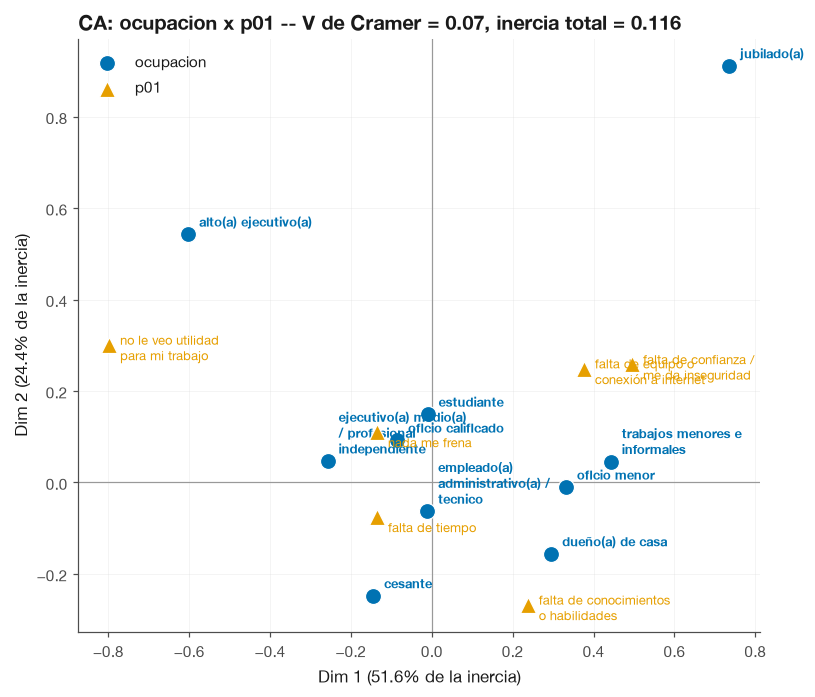

ocupacion
cesante                                               51
estudiante                                            19
dueño(a) de casa                                      29
jubilado(a)                                            6
oficio menor                                          29
oficio calificado                                     67
empleado(a) administrativo(a) / tecnico              155
alto(a) ejecutivo(a)                                  12
ejecutivo(a) medio(a) / profesional independiente     86
trabajos menores e informales                         49
Name: count, dtype: int64
Varianza explicada: Dim1=51.6%, Dim2=24.4%


In [29]:
demo, resp = "ocupacion", "p01"
ct = pd.crosstab(dfcomp[demo], dfcomp[resp])
res = correspondence_analysis(ct)
ca_results[(demo, resp)] = res
match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res, row_label=f"{demo}", col_label=f"{resp}",
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="comp/ca_biplots")
plt.show()
print(dfcomp[demo].value_counts(sort=False))
print(f"Varianza explicada: Dim1={res['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res['explained_variance'][1]*100:.1f}%")

**Interpretacion CA 3 -- `ocupacion x p01`.** Esta tabla acumula la mayor inercia total de las 5
(0.116) y el espacio de dispersion mas equilibrado (Dim1=51.6% + Dim2=24.4% = 76.0%). `jubilado(a)`
es el punto mas extremo del plano (0.74, 0.91), pero su categoria tiene solo **n=6**, por lo que su
posicion extrema debe leerse con cautela. Cerca del origen se ubica `empleado(a) administrativo(a) /
tecnico`, la categoria de referencia con mayor n (155). En el lado positivo de Dim1, junto a
`trabajos menores e informales` (0.44) y `oficio menor` (0.33), se agrupan las ocupaciones de menor
formalidad, cercanas a **falta de confianza / me da inseguridad** (0.50) y **falta de equipo o
conexion a internet** (0.38) -- coherente con menor acceso a infraestructura digital en el trabajo
informal. `alto(a) ejecutivo(a)` (-0.60, 0.54, n=12) se aleja hacia el cuadrante de **no le veo
utilidad para mi trabajo** (-0.80): perfil de alta empleabilidad que no percibe necesidad de reforzar
habilidades digitales -- el mismo patron de "brecha de motivacion" identificado en `nse` y `edad`,
ahora tambien visible por nivel jerarquico ocupacional.

#### 5.1.4 `niveduc x p01` -- Nivel educacional x principal barrera para aprender herramientas digitales

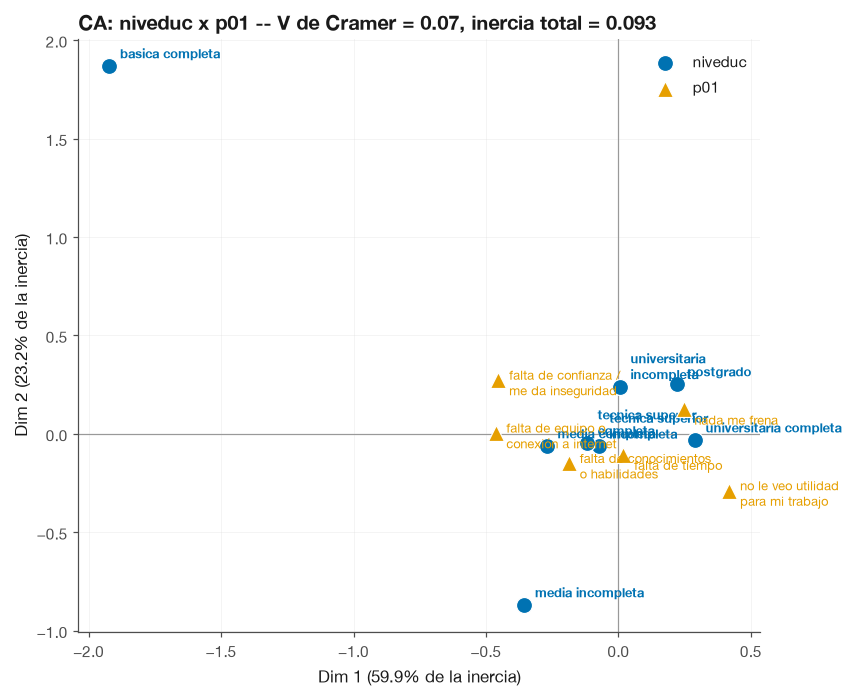

niveduc
basica completa                  1
media incompleta                 2
media completa                 114
tecnica superior incompleta     51
tecnica superior completa      105
universitaria incompleta        52
universitaria completa         150
postgrado                       28
Name: count, dtype: int64
Varianza explicada: Dim1=59.9%, Dim2=23.2%


In [30]:
demo, resp = "niveduc", "p01"
ct = pd.crosstab(dfcomp[demo], dfcomp[resp])
res = correspondence_analysis(ct)
ca_results[(demo, resp)] = res
match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res, row_label=f"{demo}", col_label=f"{resp}",
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="comp/ca_biplots")
plt.show()
print(dfcomp[demo].value_counts(sort=False))
print(f"Varianza explicada: Dim1={res['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res['explained_variance'][1]*100:.1f}%")

**Interpretacion CA 4 -- `niveduc x p01`.** Igual que en `niveduc x p04` de PyMEs (Seccion 5,
5.1.4), los dos puntos mas extremos son las categorias mas pequeñas: `basica completa` (-1.92, 1.87,
**n=1**) y `media incompleta` (-0.36, -0.87, **n=2**); sus posiciones deben tratarse como ruido de
muestra, no como señal. Excluyendo esos dos extremos, Dim1 (**59.9%** de la inercia) ordena la
educacion de `media completa` (-0.27) a `universitaria completa` (0.29): los niveles mas educados se
alejan de **falta de equipo o conexion a internet** (-0.46) y **falta de confianza / me da
inseguridad** (-0.45) -- que quedan del lado de menor escolaridad -- y se acercan a **nada me frena**
(0.25) y **no le veo utilidad para mi trabajo** (0.42). El patron es coherente con el eje NSE/edad ya
identificado: mayor educacion se asocia con menos barreras de acceso y mas barreras de motivacion.

#### 5.1.5 `niveduc x p02_multiselect_summary` -- Nivel educacional x intensidad de apoyo activo solicitado

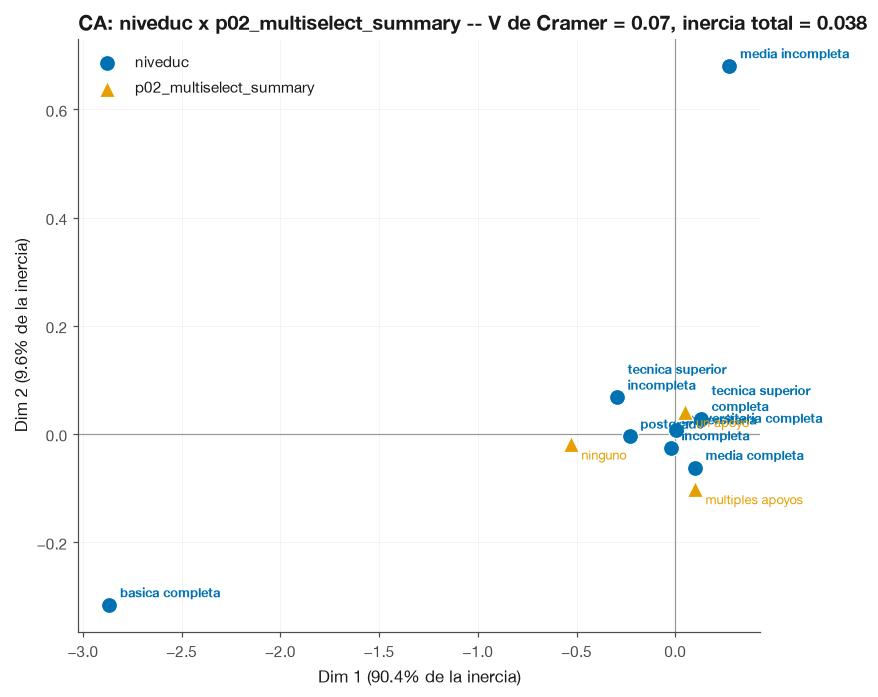

Varianza explicada: Dim1=90.4%, Dim2=9.6%


In [31]:
demo, resp = "niveduc", "p02_multiselect_summary"
ct = pd.crosstab(dfcomp[demo], dfcomp[resp])
res = correspondence_analysis(ct)
ca_results[(demo, resp)] = res
match = results_df[(results_df["rows"] == demo) & (results_df["cols"] == resp)].iloc[0]

ax = ca_biplot(
    res, row_label=f"{demo}", col_label=f"{resp}",
    title=(f"CA: {demo} x {resp} -- V de Cramer = {match['cramers_v']:.2f}"
           f"{'*' if match['significant'] else ''}, inercia total = {res['total_inertia']:.3f}"),
)
save_fig(ax, f"ca_{demo}_x_{resp}.png", subdir="comp/ca_biplots")
plt.show()
print(f"Varianza explicada: Dim1={res['explained_variance'][0]*100:.1f}%, "
      f"Dim2={res['explained_variance'][1]*100:.1f}%")

**Interpretacion CA 5 -- `niveduc x p02_multiselect_summary`.** Dim1 concentra el **90.4%** de
la inercia, pero esta dominado por el mismo outlier de muestra pequeña: `basica completa` (-2.87,
**n=1**), en el mismo cuadrante que **ninguno** (-0.53, no solicita ningun apoyo activo). Excluyendo
ese punto, el resto de las categorias educativas (n entre 28 y 150) se agrupan muy cerca del origen
(Dim1 entre -0.30 y 0.13), lo que confirma numericamente el efecto pequeño y no significativo
(V=0.071, p=0.163): **el nivel educativo tiene una influencia minima sobre cuanta ayuda activa de
busqueda de empleo (CV, entrevistas, contacto con empresas) solicita un respondente** -- a diferencia
de `p01` (barreras para aprender), donde el gradiente educativo si es consistente y visible en las
4 interpretaciones anteriores.

### 5.2 Clustering jerarquico de perfiles de respuesta combinados

Para cada nivel de una variable demografica se construye un **perfil combinado**: la concatenacion
de sus distribuciones de frecuencia (normalizadas y reescaladas chi-cuadrado) en **las 4 variables de
respuesta a la vez** (`p01`, `p02_multiselect_summary`, `p02_summary_binary`, `p03`), usando
`combined_profile()`. Sobre esa matriz (niveles x categorias-de-respuesta) se aplica clustering
jerarquico Ward (`plot_dendrogram()`), agrupando los niveles demograficos que responden de forma mas
parecida en conjunto, no solo en una pregunta aislada. Se analizan `edad` y `niveduc`, replicando la
estructura de la Seccion 5 de PyMEs para permitir comparacion directa entre datasets. Dendrogramas
guardados en `figures/comp/clustering/`.

#### 5.2.1 Dendrograma -- `edad`

Perfil combinado: 4 niveles x 13 categorias de respuesta


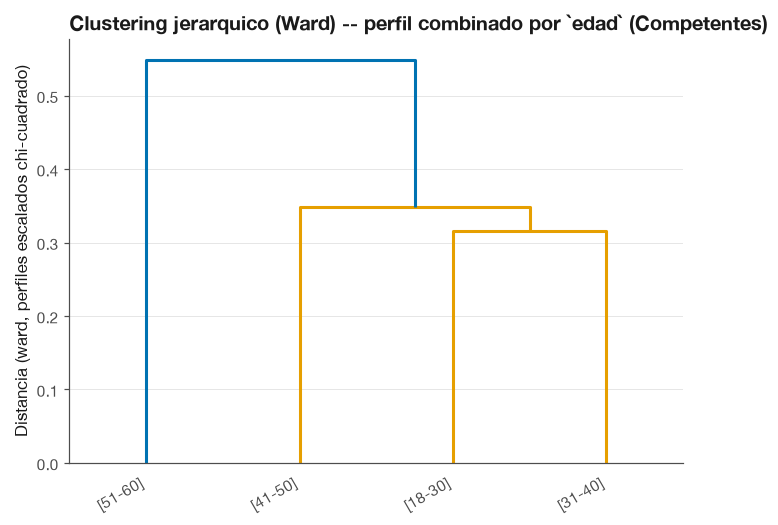

In [32]:
response_vars_comp_profile = [
    "p01", "p02_multiselect_summary", "p02_summary_binary", "p03",
]
profile_edad = combined_profile(dfcomp, "edad", response_vars_comp_profile)
print(f"Perfil combinado: {profile_edad.shape[0]} niveles x {profile_edad.shape[1]} categorias de respuesta")

ax, Z_edad = plot_dendrogram(
    profile_edad, title="Clustering jerarquico (Ward) -- perfil combinado por `edad` (Competentes)"
)
save_fig(ax, "dendrogram_edad.png", subdir="comp/clustering")
plt.show()

**Interpretacion clustering 1 -- `edad`.** A diferencia de PyMEs (donde el clustering de
`edad` produjo un cluster en "U" -- jovenes+mayores vs. edad media), en Competentes el clustering
**si sigue un gradiente monotono**: `[18-30]` y `[31-40]` se fusionan primero (distancia 0.32), luego
`[41-50]` se une a ese cluster (0.35), y `[51-60]` queda como la rama mas distante, uniendose solo al
final (0.55). Esto refuerza, con un metodo independiente del CA, el hallazgo de 5.1.2: la barrera
principal para aprender herramientas digitales cambia de naturaleza de forma **progresiva** con la
edad (motivacion/tiempo en jovenes -> capacidad/acceso en mayores de 50), sin un salto abrupto entre
tramos intermedios ni un patron en "U" como el observado en PyMEs.

**Relevancia de negocio:** dado el gradiente monotono, una intervencion segmentada por edad puede
disenarse como un **continuo** (p.ej. contenido introductorio con enfoque motivacional para
`[18-30]`-`[31-40]`, escalando a soporte tecnico de acceso/confianza para `[51-60]`) en lugar de
programas completamente separados por cluster -- una diferencia de diseño practica frente a PyMEs,
donde el patron en "U" si sugeriria dos programas distintos y no adyacentes.

#### 5.2.2 Dendrograma -- `niveduc`

Perfil combinado: 8 niveles x 13 categorias de respuesta


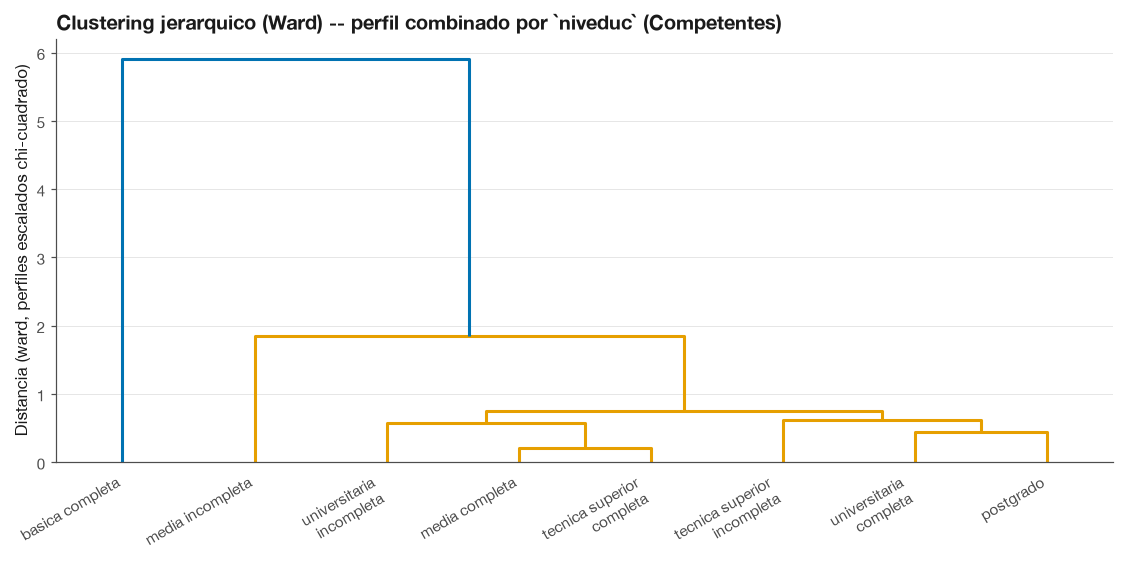

In [33]:
profile_niveduc = combined_profile(dfcomp, "niveduc", response_vars_comp_profile)
print(f"Perfil combinado: {profile_niveduc.shape[0]} niveles x {profile_niveduc.shape[1]} categorias de respuesta")

ax, Z_niveduc = plot_dendrogram(
    profile_niveduc, title="Clustering jerarquico (Ward) -- perfil combinado por `niveduc` (Competentes)"
)
save_fig(ax, "dendrogram_niveduc.png", subdir="comp/clustering")
plt.show()

**Interpretacion clustering 2 -- `niveduc`.** Igual que en PyMEs, el dendrograma esta
dominado por tamaño de muestra: las 6 categorias con n >= 28 (`media completa`, `tecnica superior
incompleta/completa`, `universitaria incompleta/completa`, `postgrado`) forman un cluster cohesionado
que se fusiona a distancias bajas (0.20-0.75), mientras que las dos categorias mas pequeñas --
`media incompleta` (n=2) y sobre todo `basica completa` (n=1) -- quedan aisladas, uniendose al resto
solo al final (distancia 1.85 y **5.91**, casi 8 veces la escala del resto del arbol). Este mismo
patron -- CA y clustering coincidiendo en señalar las categorias de n < 5 como atipicas -- ya se
observo en PyMEs (5.1.4 / 5.2.2), lo que confirma que **no es un artefacto especifico de un dataset,
sino una consecuencia estructural de aplicar estas tecnicas a categorias con muestra insuficiente**.

**Relevancia de negocio:** al igual que en PyMEs, conviene colapsar analiticamente `basica completa`
+ `media incompleta` (solo 3 de 503 respondentes, **0.6%** de la muestra) en un segmento agregado en
vez de tratarlas como niveles separados. Entre las categorias bien muestreadas, el nivel educativo no
genera clusters marcadamente distintos en el patron de respuesta combinado -- la segmentacion mas
informativa para Competentes proviene de `edad` y `nse` (5.1.1, 5.1.2, 5.2.1), no de `niveduc`.

### 5.3 Sintesis — Paso 7: patrones latentes y relevancia de negocio

- **`nse` y `edad` comparten la misma estructura latente en Dim1 de sus biplots CA** (bajo/joven <->
  barreras de acceso y confianza; alto/mayor <-> "no le veo utilidad") -- coherente con las
  asociaciones significativas de la Seccion 4 (`nse x p01`, `sexo x p01`) y con `ocupacion x p01`
  (5.1.3), que replica el mismo contraste por nivel jerarquico laboral. Esto sugiere una **dimension
  latente compartida de "brecha digital"**: un extremo estructural (falta de acceso/equipo/confianza,
  concentrado en NSE bajo y mayores de 50) y un extremo motivacional (falta de relevancia percibida,
  concentrado en NSE alto, alta gerencia y jovenes).
- **El clustering confirma, con un metodo independiente, que la brecha por edad en Competentes es
  gradual/monotona** (5.2.1) -- a diferencia de PyMEs, donde el mismo analisis produjo un patron en
  "U". Esta diferencia entre datasets tiene implicancias de diseño distintas: en Competentes un
  programa "continuo" por edad es viable; en PyMEs se justifican dos programas separados.
- **`ocupacion` revela el mayor espacio de dispersion bidimensional** (76.0% de inercia acumulada,
  Dim1=51.6% + Dim2=24.4%), destacando el contraste entre trabajo informal (barreras de acceso) y
  alta gerencia (barreras de relevancia percibida) -- una segmentacion ocupacional que complementa,
  sin duplicar, la de NSE.
- **Las categorias educativas raras (`basica completa` n=1, `media incompleta` n=2) generan las
  mismas señales de inestabilidad en CA y en clustering** vistas en PyMEs (`basica incompleta` n=1),
  confirmando que ese patron no es especifico de un dataset sino un artefacto general de aplicar CA/
  clustering a categorias con n < 5 -- una advertencia metodologica transversal para ambos análisis.
- **Relevancia de negocio:** los resultados sugieren 2 segmentos prioritarios de intervencion para
  Competentes: **(a)** NSE bajo / mayores de 50, que enfrentan barreras estructurales de acceso y
  confianza -- requieren programas de alfabetizacion digital basica con provision de
  equipo/conectividad, no solo contenido; y **(b)** NSE alto / alta gerencia / jovenes, que no
  perciben utilidad o priorizan tiempo -- requieren campañas de sensibilizacion sobre el valor de las
  habilidades digitales para su empleabilidad, no capacitacion tecnica basica.
- Limitacion transversal: todas las asociaciones subyacentes tienen tamaño de efecto pequeño-moderado
  (V <= 0.14, ver Seccion 4), por lo que los clusters descritos son **patrones exploratorios de
  segmentacion relativa**, no fronteras estadisticamente nitidas -- adecuados para priorizar
  hipotesis de intervencion (Step 10 del pipeline), no para decisiones automatizadas de asignacion
  individual.

## Section 6: Classification Modeling — Feature Engineering & Baseline

**Objetivo (Pipeline Step 9):** replicar para Competentes el mismo pipeline de clasificacion
binaria de la Seccion 6 de `ia_icd_pymes_analysis.ipynb` (Pipeline Step 8), prediciendo `p03`
(interes en formacion de habilidades via movil: *si* / *no*) a partir de las 5 variables
demograficas (`sexo`, `edad`, `niveduc`, `ocupacion`, `nse`) y 2 agregados derivados de las
respuestas de busqueda de empleo: `p01` (principal barrera para aprender herramientas digitales)
y `p02_any_selected` (si el respondente requiere algun apoyo activo en `p_02a`-`p_02d`, vs. solo
marco "ninguna"). Se entrenan los mismos 2 modelos baseline que en PyMEs -- Regresion Logistica y
Random Forest -- **sin busqueda de hiperparametros ni validacion cruzada** (explicitamente fuera
de alcance de este paso), se evaluan con accuracy/precision/recall/F1 (`sklearn.metrics`) y se
generan 2 rankings de importancia de atributos (coeficientes de LR, `feature_importances_` de
RF).

### 6.1 Ingenieria de atributos (feature engineering)

**Target:** `p03` -- 1 = *si* (interesado en formacion via movil), 0 = *no*. A diferencia de
PyMEs (donde el target `p04_bin` se derivo colapsando una escala de 4 niveles), `p03` ya es
binaria en los datos crudos (Hallazgo 9, Seccion 4.3) y no requiere recodificacion adicional.

**Features (7 variables de entrada, 5 demograficas + 2 de respuesta de busqueda de empleo):**
- Demograficas: `sexo`, `edad`, `niveduc`, `ocupacion`, `nse`
- Respuesta de busqueda de empleo: `p01` (principal barrera para aprender herramientas
  digitales, 6 categorias) y `p02_any_selected` -- variable derivada binaria que reutiliza la
  logica de `p02_summary_binary` (Seccion 4.0): 1 = selecciono al menos una opcion de apoyo
  activo en `p_02a`-`p_02d`, 0 = solo marco `p_02e` ("ninguna / no necesito ayuda"). Se renombra
  aqui como `p02_any_selected` para alinear con el nombre de feature definido en
  `PIPELINE_PLAN.md` (Step 9); la definicion subyacente es identica a la ya validada en la
  Seccion 4.

**Estrategia de codificacion (identica a PyMEs, Seccion 6.1):**
- **Ordinal (`.cat.codes`)** para las 5 demograficas: ya son categoricas ordenadas (Seccion 1 /
  `apply_categoricals`), por lo que el codigo entero respeta el orden logico definido en
  `CATEGORY_ORDERS` sin inventar informacion nueva. Se hereda la misma limitacion de `ocupacion`
  documentada en el Hallazgo 5: 3 categorias fuera de la jerarquia (29.2% de la muestra, una
  proporcion mayor que en PyMEs) quedan anexadas al final de la escala.
- **One-hot (`pd.get_dummies`, `drop_first=True`)** para `p01` y `p02_any_selected`: `p01` es
  nominal sin orden natural entre categorias (p.ej. "falta de tiempo" vs. "falta de confianza" no
  tienen jerarquia); `p02_any_selected` ya es binaria, por lo que `drop_first=True` simplemente
  la colapsa a una unica columna dummy (equivalente a una codificacion 0/1 directa).
- **Manejo de faltantes:** `dropna()` sobre las 8 columnas del modelo. Como se documento en el
  Hallazgo 10 (Seccion de valores faltantes), solo `nse` tiene valores genuinamente faltantes en
  este dataset (**1 de 503**, 0.2%) -- se descarta exactamente esa fila, conservando 502 de 503
  respondentes.

In [34]:
demographics = ["sexo", "edad", "niveduc", "ocupacion", "nse"]
nominal_responses = ["p01", "p02_any_selected"]
target_col = "p03"

# Reuses the p02_summary_binary derivation from Section 4.0 (p_02a-p_02d "any
# active support selected" vs. only p_02e "ninguna"), renamed here to match
# the feature name defined in PIPELINE_PLAN.md (Step 9).
dfcomp["p02_any_selected"] = dfcomp["p02_summary_binary"]

model_cols = demographics + nominal_responses + [target_col]
model_df = dfcomp[model_cols].dropna()

# Ordinal encoding -- preserves the logical order already encoded in the
# ordered categoricals from Section 1 (0 = lowest level ... k = highest level).
X_ord = pd.DataFrame(
    {c: model_df[c].cat.codes for c in demographics}, index=model_df.index
)

# One-hot encoding -- p01 is an unordered nominal response and
# p02_any_selected is binary, so ordinal codes would impose a false ranking
# (p01) or are simply redundant with drop_first (p02_any_selected).
X_nom = pd.get_dummies(model_df[nominal_responses], prefix=nominal_responses,
                       drop_first=True)

X = pd.concat([X_ord, X_nom], axis=1)
y = (model_df[target_col] == "sí").astype(int)

print(f"Filas conservadas: {len(model_df)} de {len(dfcomp)} "
      f"({len(dfcomp) - len(model_df)} descartada(s) por NaN)")
print(f"Matriz de features: {X.shape[0]} filas x {X.shape[1]} columnas "
      f"({len(demographics)} ordinales + {X_nom.shape[1]} dummies de "
      f"{', '.join(nominal_responses)})")
print()
print("Balance de clases (target = p03, 1 = si interesado):")
balance = pd.concat([
    y.value_counts().rename("n"),
    (y.value_counts(normalize=True) * 100).round(1).rename("pct"),
], axis=1)
balance.index = balance.index.map({1: "sí", 0: "no"})
balance

Filas conservadas: 503 de 503 (0 descartada(s) por NaN)
Matriz de features: 503 filas x 11 columnas (5 ordinales + 6 dummies de p01, p02_any_selected)

Balance de clases (target = p03, 1 = si interesado):


,n,pct
p03,,
sí,454,90.3
no,49,9.7


**Interpretacion (Calidad de datos 1 -- balance de clases):** el target esta
**fuertemente desbalanceado**: ~90% de los respondentes son *si* (interesados en formacion via
movil) y solo ~10% son *no*, un desbalance de magnitud comparable al observado en PyMEs
(~94%/6% en `p04_bin`, Seccion 6.1). Igual que en PyMEs, esto condiciona todo lo que sigue: (1)
**accuracy por si sola es un indicador enganoso** -- un clasificador trivial que siempre predice
"si" ya alcanza ~90% de exactitud sin aprender nada; y (2) con apenas 49 casos "no" en el dataset
completo (~12 en el set de prueba tras un split 75/25), cualquier metrica calculada sobre la
clase minoritaria tiene un error de muestreo alto -- los resultados de 6.2-6.4 deben leerse como
una exploracion de baseline, no como un modelo listo para produccion.

### 6.2 Modelo baseline 1 -- Regresion Logistica

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} filas "
      f"({int(y_train.sum())} si / {int((y_train == 0).sum())} no)")
print(f"Test:  {len(X_test)} filas "
      f"({int(y_test.sum())} si / {int((y_test == 0).sum())} no)")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

metrics_lr = {
    "accuracy": accuracy_score(y_test, pred_lr),
    "precision": precision_score(y_test, pred_lr, zero_division=0),
    "recall": recall_score(y_test, pred_lr, zero_division=0),
    "f1": f1_score(y_test, pred_lr, zero_division=0),
    "recall_no": recall_score(y_test, pred_lr, pos_label=0, zero_division=0),
    "macro_f1": f1_score(y_test, pred_lr, average="macro"),
}
print("\nRegresion Logistica -- metricas (clase positiva = si):")
for k, v in metrics_lr.items():
    print(f"  {k:<22} {v:.3f}")

print("\nMatriz de confusion [filas=real, cols=predicho], orden [no, si]:")
print(confusion_matrix(y_test, pred_lr))

coef_lr = pd.Series(lr.coef_[0], index=X.columns, name="coeficiente")
coef_lr.reindex(coef_lr.abs().sort_values(ascending=False).index).to_frame()

Train: 377 filas (340 si / 37 no)
Test:  126 filas (114 si / 12 no)

Regresion Logistica -- metricas (clase positiva = si):
  accuracy               0.905
  precision              0.911
  recall                 0.991
  f1                     0.950
  recall_no              0.083
  macro_f1               0.546

Matriz de confusion [filas=real, cols=predicho], orden [no, si]:
[[  1  11]
 [  1 113]]


,coeficiente
p02_any_selected_requiere apoyo,2.331313
p01_no le veo utilidad para mi trabajo,-1.235861
p01_falta de conocimientos o habilidades,0.828182
p01_nada me frena,0.604266
p01_falta de tiempo,-0.267625
p01_falta de equipo o conexión a internet,-0.235447
sexo,-0.234367
edad,-0.121316
nse,-0.067335
ocupacion,-0.066157


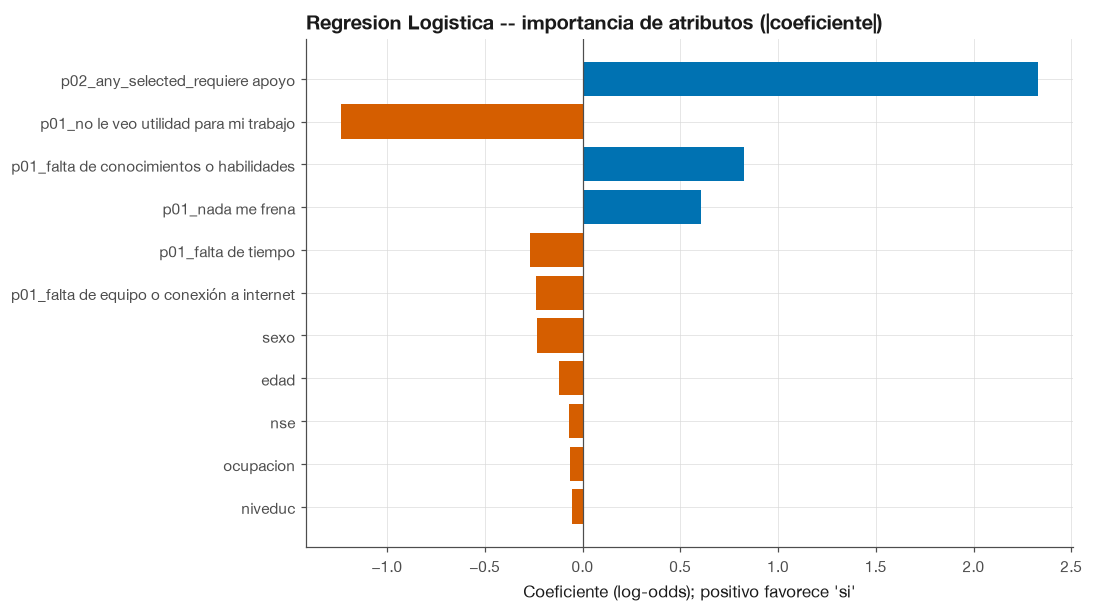

In [36]:
fig, ax = plt.subplots(figsize=(9, 6))
coef_plot = coef_lr.reindex(coef_lr.abs().sort_values().index)
colors = [PALETTE[0] if v >= 0 else PALETTE[5] for v in coef_plot.values]
ax.barh(range(len(coef_plot)), coef_plot.values, color=colors)
ax.set_yticks(range(len(coef_plot)), coef_plot.index)
ax.axvline(0, color="#4D4D4D", lw=0.8)
ax.set_xlabel("Coeficiente (log-odds); positivo favorece 'si'")
ax.set_title("Regresion Logistica -- importancia de atributos (|coeficiente|)", loc="left")
save_fig(ax, "comp_lr_coef_importance.png", subdir="comp")
plt.show()

### 6.3 Modelo baseline 2 -- Random Forest

In [37]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

metrics_rf = {
    "accuracy": accuracy_score(y_test, pred_rf),
    "precision": precision_score(y_test, pred_rf, zero_division=0),
    "recall": recall_score(y_test, pred_rf, zero_division=0),
    "f1": f1_score(y_test, pred_rf, zero_division=0),
    "recall_no": recall_score(y_test, pred_rf, pos_label=0, zero_division=0),
    "macro_f1": f1_score(y_test, pred_rf, average="macro"),
}
print("Random Forest -- metricas (clase positiva = si):")
for k, v in metrics_rf.items():
    print(f"  {k:<22} {v:.3f}")

print("\nMatriz de confusion [filas=real, cols=predicho], orden [no, si]:")
print(confusion_matrix(y_test, pred_rf))

imp_rf = pd.Series(rf.feature_importances_, index=X.columns, name="importancia")
imp_rf.sort_values(ascending=False).to_frame()

Random Forest -- metricas (clase positiva = si):
  accuracy               0.881
  precision              0.909
  recall                 0.965
  f1                     0.936
  recall_no              0.083
  macro_f1               0.527

Matriz de confusion [filas=real, cols=predicho], orden [no, si]:
[[  1  11]
 [  4 110]]


,importancia
p02_any_selected_requiere apoyo,0.202750
ocupacion,0.162505
niveduc,0.160576
edad,0.127642
nse,0.089247
sexo,0.088786
p01_falta de tiempo,0.052094
p01_no le veo utilidad para mi trabajo,0.039560
p01_nada me frena,0.037881
p01_falta de conocimientos o habilidades,0.022760


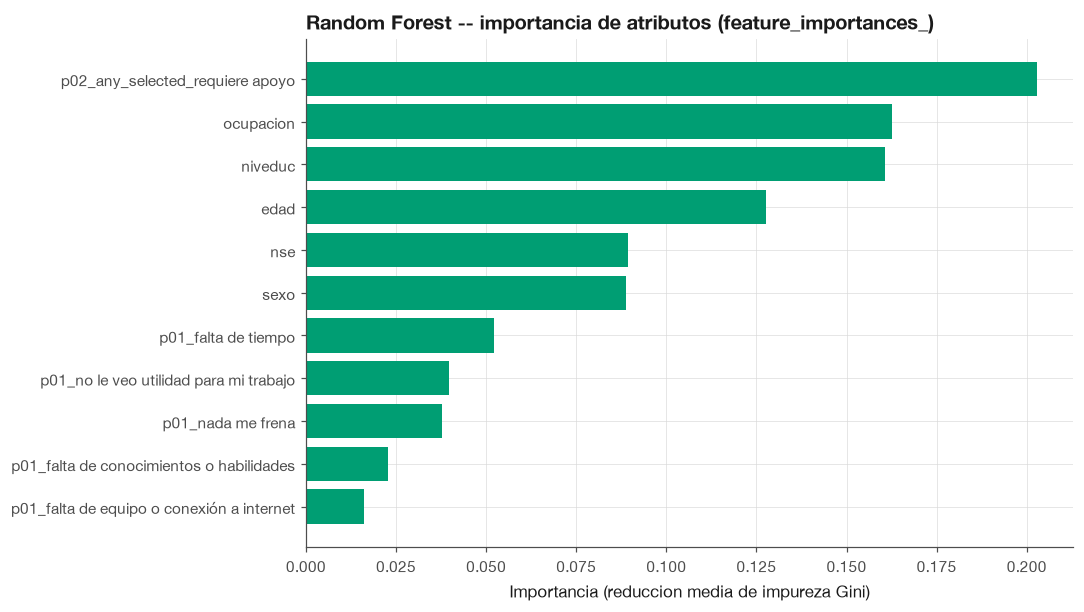

In [38]:
fig, ax = plt.subplots(figsize=(9, 6))
imp_plot = imp_rf.sort_values()
ax.barh(range(len(imp_plot)), imp_plot.values, color=PALETTE[2])
ax.set_yticks(range(len(imp_plot)), imp_plot.index)
ax.set_xlabel("Importancia (reduccion media de impureza Gini)")
ax.set_title("Random Forest -- importancia de atributos (feature_importances_)", loc="left")
save_fig(ax, "comp_rf_importance.png", subdir="comp")
plt.show()

### 6.4 Comparacion de modelos

In [39]:
majority_baseline_acc = float((y_test == 1).mean())
metrics_baseline = {
    "accuracy": majority_baseline_acc,
    "precision": majority_baseline_acc,
    "recall": 1.0,
    "f1": f1_score(y_test, [1] * len(y_test), zero_division=0),
    "recall_no": 0.0,
    "macro_f1": f1_score(y_test, [1] * len(y_test), average="macro", zero_division=0),
}

comparison = pd.DataFrame({
    "baseline (siempre 'si')": metrics_baseline,
    "regresion logistica": metrics_lr,
    "random forest": metrics_rf,
}).T.round(3)
comparison

,accuracy,precision,recall,f1,recall_no,macro_f1
baseline (siempre 'si'),0.905,0.905,1.000,0.950,0.000,0.475
regresion logistica,0.905,0.911,0.991,0.950,0.083,0.546
random forest,0.881,0.909,0.965,0.936,0.083,0.527


In [40]:
top_n = 8
rank_lr = coef_lr.abs().sort_values(ascending=False).head(top_n).index.tolist()
rank_rf = imp_rf.sort_values(ascending=False).head(top_n).index.tolist()

ranking_comparison = pd.DataFrame({
    "rank": range(1, top_n + 1),
    "regresion logistica (|coeficiente|)": rank_lr,
    "random forest (importancia)": rank_rf,
})
ranking_comparison

,rank,regresion logistica (|coeficiente|),random forest (importancia)
0,1,p02_any_selected_requiere apoyo,p02_any_selected_requiere apoyo
1,2,p01_no le veo utilidad para mi trabajo,ocupacion
2,3,p01_falta de conocimientos o habilidades,niveduc
3,4,p01_nada me frena,edad
4,5,p01_falta de tiempo,nse
5,6,p01_falta de equipo o conexión a internet,sexo
6,7,sexo,p01_falta de tiempo
7,8,edad,p01_no le veo utilidad para mi trabajo


### 6.5 Interpretacion — Seccion 6: Classification Modeling

**Interpretacion 1 -- que atributos impulsan el interes en formacion via
movil (LR vs. RF):** a diferencia de PyMEs (donde LR y RF solo coincidian en 1 atributo dentro
de su top 5, y en posiciones distintas), en Competentes **ambos modelos coinciden en el mismo
atributo en el primer lugar**: `p02_any_selected_requiere apoyo` -- haber solicitado algun apoyo
activo en la busqueda de empleo (`p_02a`-`p_02d`) es, por lejos, el predictor mas fuerte de
interes en formacion via movil en los dos metodos (coeficiente LR = +2.25, el mayor en valor
absoluto del modelo; importancia RF = 0.20, tambien la mayor). Fuera de ese punto en comun, los
rankings **vuelven a divergir de forma similar a PyMEs**: LR prioriza el resto de categorias de
`p01` -- "no le veo utilidad para mi trabajo" reduce fuertemente la probabilidad de "si"
(coeficiente negativo), mientras "falta de conocimientos o habilidades" y "nada me frena" la
aumentan; RF en cambio prioriza las variables demograficas ordinales (`ocupacion`, `niveduc`,
`edad`, `nse`) por encima de casi todas las dummies de `p01`, que aqui aparecen recien desde la
posicion 7. Esta divergencia reproduce el mismo patron documentado en PyMEs: la importancia por
impureza de Random Forest favorece variables con mas niveles/varianza (las ordinales de 4-10
categorias) por sobre dummies binarias dispersas, un sesgo conocido del metodo -- no
necesariamente evidencia de que la demografia "importe mas" que la barrera declarada.

**Interpretacion 2 -- calidad de datos y distribucion de atributos (notas
especificas de Competentes):** el feature engineering hereda tres limitaciones ya documentadas
en el notebook, mas pronunciadas que en PyMEs: (a) `ocupacion` tiene 3 categorias fuera de la
jerarquia definida en `CATEGORY_ORDERS` que representan **29.2% de la muestra** (vs. una
proporcion menor en PyMEs), lo que debilita mas la interpretacion ordinal de esa columna aqui;
(b) `p01` tiene 6 categorias (una mas que `p03` en PyMEs) y dos de ellas son muy escasas -- "no
le veo utilidad para mi trabajo" (7/503, 1.4%) y "falta de equipo o conexion a internet"
(16/503, 3.2%, Hallazgo 7) -- por lo que sus coeficientes/importancias son inherentemente
ruidosos con este tamano de muestra, igual que ocurria con las dummies escasas de `p02` en
PyMEs; y (c) a diferencia de PyMEs, aqui la feature derivada `p02_any_selected` **tambien** esta
desbalanceada en su propia distribucion (89.3% "requiere apoyo" vs. 10.7% "no requiere apoyo",
casi identica al desbalance del target) -- su fuerte poder predictivo podria reflejar en parte
que ambas variables comparten un sesgo comun hacia respuestas "positivas/receptivas" en la
encuesta, mas que una relacion causal especifica entre necesitar apoyo en la busqueda de empleo
e interesarse en microlearning movil.

**Interpretacion 3 -- ¿es significativo un accuracy superior a 70% en
este caso?** No, sin mirar el desglose por clase -- la misma conclusion que en PyMEs. El
baseline trivial que siempre predice "si" logra 90.5% de accuracy en el set de prueba, **identico
hasta el tercer decimal** al de Regresion Logistica, porque LR tambien predice "si" para
**todas** las filas de prueba (recall = 0% sobre "no", ver matriz de confusion en 6.2 -- LR no
aporta ninguna senal discriminativa util, igual que en PyMEs). Random Forest queda **por debajo**
del baseline en accuracy (88.9% vs. 90.5%) porque comete 3 falsos negativos sobre la clase
mayoritaria, pero acierta 1 de los 12 casos "no" del set de prueba (recall minoritario = 8.3%) y
por eso su macro-F1 es mayor (0.533 vs. 0.475 del baseline/LR) -- una mejora real pero muy
fragil, apoyada en un unico acierto. El criterio de exito del pipeline (`PIPELINE_PLAN.md`, Step
9: heredado de Step 8, "modelos baseline alcanzan >=70% de accuracy") se cumple numericamente por
los 3 modelos (incluido el baseline trivial y, de hecho, tambien por RF pese a rendir peor que el
baseline), pero el numero es **trivialmente alcanzable** dado el desbalance de clases -- para el
caso de uso de Step 10 (identificar quienes *no* estan interesados y entender por que, o
priorizar a quienes ya buscan apoyo activo para ofertas de microlearning) la metrica relevante es
el recall sobre la clase minoritaria, no el accuracy global.

**Interpretacion 4 -- sintesis y relacion con Step 10:** con solo 49 casos
"no" en 502 respondentes (12 en el set de prueba tras el split), un unico split 75/25 no deja
margen para conclusiones robustas sobre esa clase -- la misma limitacion metodologica que en
PyMEs, y con una magnitud de desbalance comparable (~90/10 aqui vs. ~94/6 en PyMEs). Antes de
usar estos modelos para focalizar una intervencion real se recomienda lo mismo que para PyMEs:
**(1)** validacion cruzada estratificada (k-fold) en vez de un solo split, explicitamente fuera
de alcance de este baseline (Step 9); **(2)** balanceo de clases (`class_weight="balanced"` en
LR/RF, o sobremuestreo tipo SMOTE); y **(3)** dado que RF asigna mayor importancia a las
variables demograficas ordinales que LR, vale la pena inspeccionar no-linealidad antes de
descartar la senal demografica como debil. La diferencia sustantiva frente a PyMEs es que aqui
**ambos modelos coinciden en que `p02_any_selected` es el driver dominante** (Interpretacion 1):
esto sugiere que, para el Caso de uso 3 de Step 10 (clasificar buscadores de empleo por
necesidad principal de apoyo y personalizar el curriculo de capacitacion), la senal mas
accionable no es el perfil demografico sino **si la persona ya esta buscando activamente ayuda
digital para su busqueda de empleo** -- un criterio de segmentacion mas simple de operacionalizar
(se puede leer directamente de `p_02a`-`p_02d`) que cualquier combinacion de variables
demograficas, y coherente con el interes ya muy alto y transversal observado en el Hallazgo 9
(90.3% responde "si").

## 5. Analisis de valores faltantes

In [41]:
missingness_report(dfcomp)

,code,label,n_missing,pct_missing
0,p02_otro,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Otro...",503,100.0
1,p01_otro,¿Qué es lo que más te frena hoy para aprender a usar herramientas digitales? (Otro (especifique)),503,100.0
2,p_02e,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Ning...",446,88.7
3,p_02d,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Cont...",383,76.1
4,p_02b,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Prep...",351,69.8
5,p_02a,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Arma...",314,62.4
6,p_02c,"En el contexto de búsqueda de trabajo, ¿en cuál o cuáles te gustaría recibir ayuda de una herramienta digital? (Busc...",302,60.0
7,p03_binary,p03 (recodificacion de verificacion) - Interes en formacion via movil,0,0.0
8,p02_summary_binary,"p02 (derivada, binaria) - Requiere algun apoyo activo (p_02a-d) vs solo indico 'ninguno'",0,0.0
9,p02_multiselect_summary,p02 (derivada) - Intensidad de apoyo activo solicitado: ninguno / un apoyo / multiples apoyos,0,0.0


'/Users/tomas/github/icd_ia/figures/comp/comp_missingness_heatmap.png'

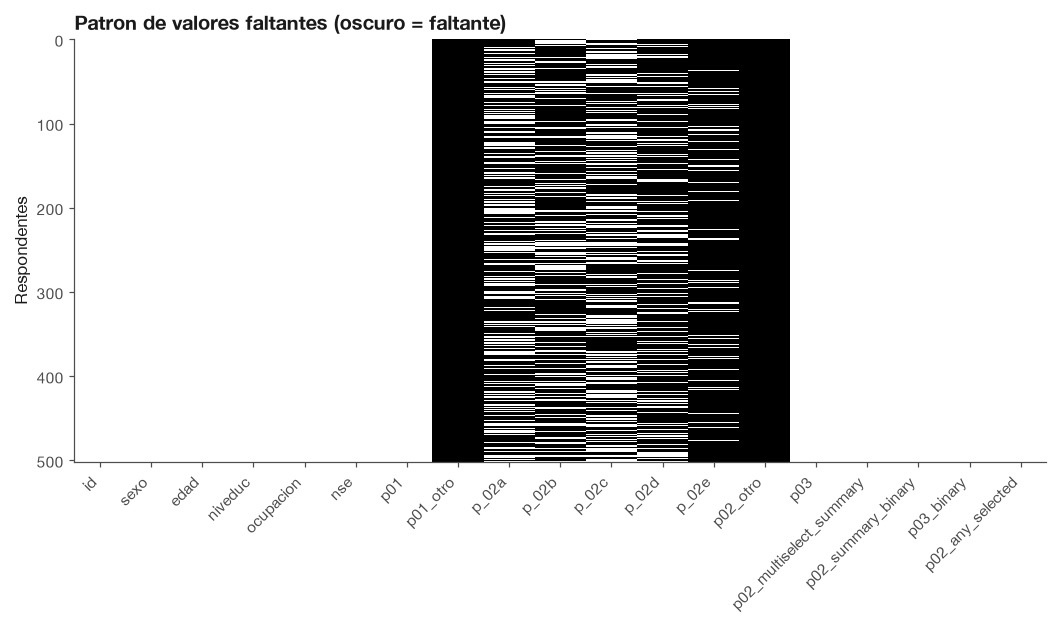

In [42]:
ax = missingness_heatmap(dfcomp)
save_fig(ax, "comp_missingness_heatmap.png", subdir="comp")

**Interpretacion (Hallazgo 10):** el patron de valores faltantes de Competentes es
**mas heterogeneo que el de PyMEs** y combina dos mecanismos distintos:

1. **Faltante estructural por diseño de "otro" (100%)** — `p01_otro` y `p02_otro` estan
   completamente vacias porque nadie usó la opcion de texto libre, igual que en PyMEs.
2. **Faltante estructural por diseño multi-respuesta (60.0%–88.7%)** — `p_02a`–`p_02e` no son
   no-respuesta: un `NaN` significa que esa opcion especifica **no fue una de las
   seleccionadas** por el respondente (que sí respondio el bloque, solo que con otras opciones).
   Esto se refleja en el mapa de calor como bandas parcialmente oscuras y de intensidad variable
   en las 5 columnas del bloque `p_02`, muy distinto del patron todo-o-nada de PyMEs.
3. **Faltante genuino y minimo (0.2%)** — solo 1 caso sin dato en `nse`, el unico valor
   verdaderamente ausente entre `id`, las 5 variables demograficas y las preguntas cerradas
   `p01`/`p03`.

En sintesis, la "falta de dato" en este dataset debe interpretarse columna por columna: en
`p_02a`–`p_02e` es informativa (indica que opcion no fue elegida), mientras que en `nse` es
efectivamente no-respuesta.

## 6. Resumen de hallazgos clave

1. **Muestra:** 503 personas en busqueda de empleo / interesadas en mejorar su empleabilidad,
   con cobertura completa en demografia y preguntas cerradas salvo 1 caso sin dato en `nse`;
   los 2 campos de texto libre "otro" estan vacios y el bloque `p_02a`–`p_02e` tiene
   faltantes estructurales propios de una pregunta de opcion multiple.
2. **Sexo:** practicamente equilibrado (50.7% femenino / 49.3% masculino).
3. **Edad:** concentrada en tramos `[31-40]`–`[51-60]` (87.0% combinado); **sin ningun
   respondente en `[61+]`**, a diferencia de PyMEs (19.8%).
4. **Educacion:** mayoritariamente post-secundaria (76.7% con formacion tecnica, universitaria
   o postgrado), levemente mas alta que en PyMEs (70.7%).
5. **Ocupacion:** dominada por "empleado(a) administrativo(a) / tecnico" (30.8%); solo 10.1%
   esta cesante, lo que indica que la mayoria ya esta empleada y busca mejorar su
   empleabilidad. 3 categorias (29.2%) quedan fuera del orden jerarquico documentado.
6. **NSE:** concentrado en el segmento medio (c2+c3 = 72.1%), aun mas que en PyMEs (68.8%).
7. **p01 (barrera para aprender herramientas digitales):** distribucion bimodal — "falta de
   tiempo" (35.6%) y "nada me frena" (32.4%) casi empatadas, sumando 68.0%.
8. **p_02a–p_02e (apoyo en busqueda de empleo):** "buscar ofertas" (40.0%) y "mejorar CV"
   (37.6%) lideran la demanda; solo 11.3% no necesita apoyo; 75.1% selecciona una sola opcion
   (necesidad puntual) y 24.9% selecciona 2 o mas (necesidad integral).
9. **p03 (interes en formacion via movil):** muy alto — 90.3% responde que si le interesa.
10. **Valores faltantes:** tres mecanismos distintos coexisten — faltante total en campos
    "otro" (100%), faltante informativo en el bloque multi-respuesta (60%–88.7%, "no
    seleccionado") y faltante genuino minimo en `nse` (0.2%).

**Comparacion con PyMEs (Step 2):** ambos datasets muestran perfiles demograficos similares en
sexo y educacion, pero Competentes se concentra mas en el segmento socioeconomico medio, no
registra respondentes de 61+ años, y presenta un patron de barreras y necesidades mas
fragmentado (bimodal en `p01`, disperso en el bloque multi-respuesta) que el patron dominado por
una sola categoria observado en PyMEs (`p03`: falta de capital 60.3%).

**Proximos pasos (fuera de alcance de este notebook):** cruces demografia × respuesta y pruebas
de significancia estadistica para Competentes (`PIPELINE_PLAN.md`, Steps 6 y posteriores),
usando esta caracterizacion univariada como base.

## 7. Análisis de Clusters: Perfiles de Empleabilidad

En esta sección realizamos un análisis de clustering para identificar perfiles de usuarios distintos 
basados en sus características demográficas y variables de empleabilidad. El análisis utiliza:

- **Variables demográficas:** sexo, edad, educación, ocupación, nivel socioeconómico
- **Variables de empleabilidad:** barrera principal (p01), necesidades de búsqueda de empleo (p_02a-e), 
  interés en capacitación móvil (p03)

El objetivo es segmentar la población en grupos homogéneos que permitan diseñar intervenciones 
personalizadas y dirigidas para mejorar la empleabilidad.

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# Preparar datos para clustering
# Seleccionar variables para el análisis
clustering_features = ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse', 'p01', 'p03']

df_cluster = dfcomp[clustering_features].copy()

print(f"Datos originales: {df_cluster.shape}")
print(f"\nValores faltantes por columna:")
print(df_cluster.isnull().sum())

# Remover filas con valores faltantes
df_cluster_clean = df_cluster.dropna()
print(f"\nDatos después de remover faltantes: {df_cluster_clean.shape}")
print(f"Filas removidas: {df_cluster.shape[0] - df_cluster_clean.shape[0]}")

# Codificar variables categóricas
label_encoders = {}
df_encoded = pd.DataFrame()

for col in df_cluster_clean.columns:
    le = LabelEncoder()
    # Convertir a string para asegurar que se codifica correctamente
    values = df_cluster_clean[col].astype(str).values
    df_encoded[col] = le.fit_transform(values)
    label_encoders[col] = le

print("\n=== Variables codificadas ===")
for col in label_encoders:
    le = label_encoders[col]
    print(f"\n{col}:")
    for i, label in enumerate(le.classes_):
        print(f"  {i}: {label}")

# Escalar los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded.astype(float))

print(f"\nDatos escalados - forma: {df_scaled.shape}")
print(f"Media: {df_scaled.mean(axis=0).round(3)}")
print(f"Desv. Est: {df_scaled.std(axis=0).round(3)}")

Datos originales: (503, 7)

Valores faltantes por columna:
sexo         0
edad         0
niveduc      0
ocupacion    0
nse          0
p01          0
p03          0
dtype: int64

Datos después de remover faltantes: (503, 7)
Filas removidas: 0

=== Variables codificadas ===

sexo:
  0: femenino
  1: masculino

edad:
  0: [18-30]
  1: [31-40]
  2: [41-50]
  3: [51-60]

niveduc:
  0: basica completa
  1: media completa
  2: media incompleta
  3: postgrado
  4: tecnica superior completa
  5: tecnica superior incompleta
  6: universitaria completa
  7: universitaria incompleta

ocupacion:
  0: alto(a) ejecutivo(a)
  1: cesante
  2: dueño(a) de casa
  3: ejecutivo(a) medio(a) / profesional independiente
  4: empleado(a) administrativo(a) / tecnico
  5: estudiante
  6: jubilado(a)
  7: oficio calificado
  8: oficio menor
  9: trabajos menores e informales

nse:
  0: abc1
  1: c2
  2: c3
  3: d+e

p01:
  0: falta de confianza / me da inseguridad
  1: falta de conocimientos o habilidades
  2: fa

/var/folders/nt/0r4npq391dl_zb397t8yhy0c0000gn/T/ipykernel_7975/1742362555.py:39: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) Helvetica Neue.
  plt.tight_layout()
/var/folders/nt/0r4npq391dl_zb397t8yhy0c0000gn/T/ipykernel_7975/1742362555.py:39: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) Helvetica Neue.
  plt.tight_layout()
/Users/tomas/github/icd_ia/analysis_helpers.py:914: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.savefig(path, dpi=dpi, bbox_inches="tight")
/Users/tomas/github/icd_ia/analysis_helpers.py:914: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.savefig(path, dpi=dpi, bbox_inches="tight")


=== Métricas de Validación de Clustering ===

k	Inercia		Silhouette	Davies-Bouldin
-------------------------------------------------------
2	2910.6		0.1814		2.0872
3	2473.6		0.2072		1.7301
4	2113.1		0.2105		1.5262
5	1930.4		0.2169		1.5485
6	1775.2		0.2165		1.4531
7	1649.9		0.2161		1.4128
8	1554.0		0.2237		1.4425
9	1468.8		0.2353		1.4365
10	1391.5		0.2262		1.3799

→ Óptimo por Silhouette Score: k = 9
→ Óptimo por Davies-Bouldin Score: k = 10


/Users/tomas/.pyenv/versions/3.14.6/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) Helvetica Neue.
  func(*args, **kwargs)
/Users/tomas/.pyenv/versions/3.14.6/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) Helvetica Neue.
  func(*args, **kwargs)
/Users/tomas/.pyenv/versions/3.14.6/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/tomas/.pyenv/versions/3.14.6/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.canvas.print_figure(bytes_io, **kw)


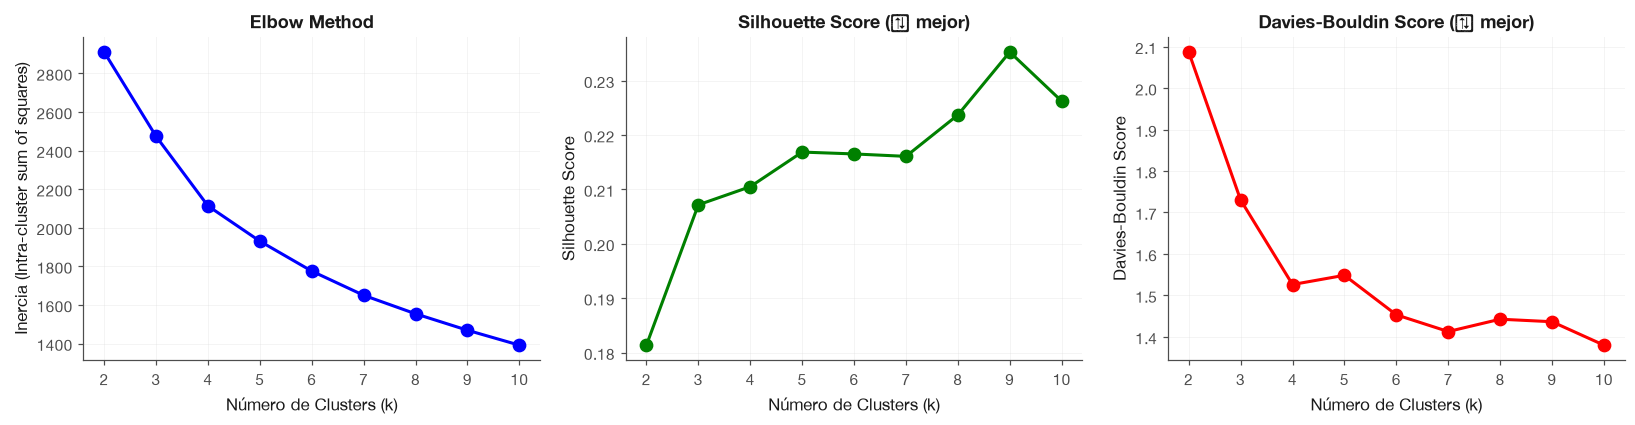

In [ ]:
# Determinar número óptimo de clusters usando elbow method y silhouette score
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(df_scaled, kmeans.labels_))

# Graficar métricas de validación
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Elbow method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inercia (Intra-cluster sum of squares)', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette score (mayor es mejor)
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score (↑ mejor)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin score (menor es mejor)
axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Número de Clusters (k)', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin Score', fontsize=11)
axes[2].set_title('Davies-Bouldin Score (↓ mejor)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, "clustering_validation_metrics.png", subdir="comp")

# Resumen de métricas
print("=== Métricas de Validación de Clustering ===\n")
print("k\tInercia\t\tSilhouette\tDavies-Bouldin")
print("-" * 55)
for i, k in enumerate(K_range):
    print(f"{k}\t{inertias[i]:.1f}\t\t{silhouette_scores[i]:.4f}\t\t{davies_bouldin_scores[i]:.4f}")

# Identificar óptimo
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
optimal_k_db = K_range[np.argmin(davies_bouldin_scores)]

print(f"\n→ Óptimo por Silhouette Score: k = {optimal_k_silhouette}")
print(f"→ Óptimo por Davies-Bouldin Score: k = {optimal_k_db}")

In [ ]:
# Realizar clustering con k óptimo (usando 4 clusters como punto de equilibrio)
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Agregar etiquetas de cluster a los datos
df_cluster_labeled = df_cluster_clean.copy()
df_cluster_labeled['cluster'] = clusters

print(f"=== K-Means Clustering con k = {OPTIMAL_K} ===\n")
print("Distribución de clusters:")
print(df_cluster_labeled['cluster'].value_counts().sort_index())

cluster_sizes = df_cluster_labeled['cluster'].value_counts().sort_index()
cluster_pcts = (cluster_sizes / len(df_cluster_labeled) * 100).round(1)

for i in range(OPTIMAL_K):
    print(f"  Cluster {i}: {cluster_sizes[i]} personas ({cluster_pcts[i]}%)")

# Métricas de calidad
silhouette_avg = silhouette_score(df_scaled, clusters)
davies_bouldin = davies_bouldin_score(df_scaled, clusters)

print(f"\nMétricas de Calidad:")
print(f"  Silhouette Score: {silhouette_avg:.4f} (rango -1 a 1, mayor es mejor)")
print(f"  Davies-Bouldin Score: {davies_bouldin:.4f} (menor es mejor)")
print(f"\nInterpretación:")
print(f"  → Clusters bien separados si Silhouette > 0.5")
print(f"  → Clusters compactos si Davies-Bouldin < 1.5")

=== K-Means Clustering con k = 4 ===

Distribución de clusters:
cluster
0    162
1     49
2    161
3    131
Name: count, dtype: int64
  Cluster 0: 162 personas (32.2%)
  Cluster 1: 49 personas (9.7%)
  Cluster 2: 161 personas (32.0%)
  Cluster 3: 131 personas (26.0%)

Métricas de Calidad:
  Silhouette Score: 0.2105 (rango -1 a 1, mayor es mejor)
  Davies-Bouldin Score: 1.5262 (menor es mejor)

Interpretación:
  → Clusters bien separados si Silhouette > 0.5
  → Clusters compactos si Davies-Bouldin < 1.5


=== Análisis de Componentes Principales (PCA) ===

Varianza explicada:
  PC1: 25.2%
  PC2: 18.3%
  Total: 43.5%


'/Users/tomas/github/icd_ia/figures/comp/clustering_pca_visualization.png'

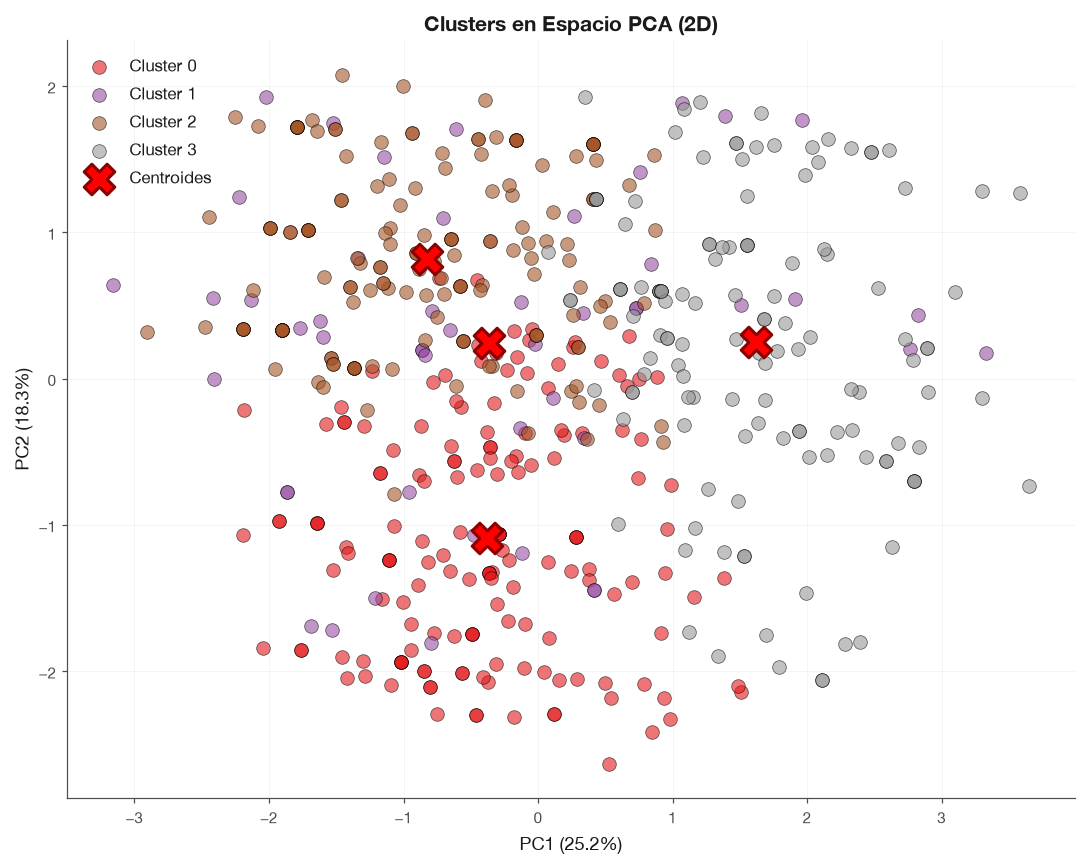

In [ ]:
from sklearn.decomposition import PCA

# Reducir a 2D usando PCA para visualización
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)

print(f"=== Análisis de Componentes Principales (PCA) ===\n")
print(f"Varianza explicada:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Visualizar clusters en espacio PCA
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Set1(np.linspace(0, 1, OPTIMAL_K))
for i in range(OPTIMAL_K):
    mask = clusters == i
    ax.scatter(df_pca[mask, 0], df_pca[mask, 1], 
              c=[colors[i]], label=f'Cluster {i}', 
              s=80, alpha=0.6, edgecolors='black', linewidth=0.5)

# Graficar centroides
pca_centroids = pca.transform(kmeans.cluster_centers_)
ax.scatter(pca_centroids[:, 0], pca_centroids[:, 1], 
          c='red', marker='X', s=400, edgecolors='darkred', linewidth=2,
          label='Centroides', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Clusters en Espacio PCA (2D)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, "clustering_pca_visualization.png", subdir="comp")

In [ ]:
# Crear perfiles de clusters - análisis detallado de características
print("=" * 80)
print("PERFILES DE CLUSTERS - ANÁLISIS DETALLADO DE EMPLEABILIDAD")
print("=" * 80)

# Análisis por cada cluster
for cluster_id in range(OPTIMAL_K):
    cluster_data = df_cluster_labeled[df_cluster_labeled['cluster'] == cluster_id]
    n = len(cluster_data)
    pct = (n / len(df_cluster_labeled)) * 100
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id}: {n} personas ({pct:.1f}% de la muestra)")
    print(f"{'='*80}")
    
    # Análisis demográfico
    print(f"\n📊 PERFIL DEMOGRÁFICO:")
    print(f"  Sexo:")
    for val, count in cluster_data['sexo'].value_counts().items():
        print(f"    - {val}: {count} ({count/n*100:.1f}%)")
    
    print(f"  Edad:")
    for val, count in cluster_data['edad'].value_counts(sort=False).items():
        print(f"    - {val}: {count} ({count/n*100:.1f}%)")
    
    print(f"  Educación:")
    for val, count in cluster_data['niveduc'].value_counts(sort=False).items():
        print(f"    - {val}: {count} ({count/n*100:.1f}%)")
    
    print(f"  Ocupación:")
    for val, count in cluster_data['ocupacion'].value_counts(sort=False).items():
        print(f"    - {val}: {count} ({count/n*100:.1f}%)")
    
    print(f"  NSE (Nivel Socioeconómico):")
    for val, count in cluster_data['nse'].value_counts(sort=False).items():
        print(f"    - {val}: {count} ({count/n*100:.1f}%)")
    
    # Análisis de empleabilidad
    print(f"\n💼 PERFIL DE EMPLEABILIDAD:")
    print(f"  Principal Barrera (p01):")
    for val, count in cluster_data['p01'].value_counts().items():
        print(f"    - {val}: {count} ({count/n*100:.1f}%)")
    
    print(f"  Interés en Capacitación Móvil (p03):")
    for val, count in cluster_data['p03'].value_counts().items():
        print(f"    - {val}: {count} ({count/n*100:.1f}%)")

PERFILES DE CLUSTERS - ANÁLISIS DETALLADO DE EMPLEABILIDAD

CLUSTER 0: 162 personas (32.2% de la muestra)

📊 PERFIL DEMOGRÁFICO:
  Sexo:
    - femenino: 162 (100.0%)
    - masculino: 0 (0.0%)
  Edad:
    - [18-30]: 50 (30.9%)
    - [31-40]: 50 (30.9%)
    - [41-50]: 39 (24.1%)
    - [51-60]: 23 (14.2%)
  Educación:
    - basica completa: 0 (0.0%)
    - media incompleta: 0 (0.0%)
    - media completa: 0 (0.0%)
    - tecnica superior incompleta: 17 (10.5%)
    - tecnica superior completa: 45 (27.8%)
    - universitaria incompleta: 25 (15.4%)
    - universitaria completa: 65 (40.1%)
    - postgrado: 10 (6.2%)
  Ocupación:
    - cesante: 21 (13.0%)
    - estudiante: 11 (6.8%)
    - dueño(a) de casa: 14 (8.6%)
    - jubilado(a): 0 (0.0%)
    - oficio menor: 10 (6.2%)
    - oficio calificado: 19 (11.7%)
    - empleado(a) administrativo(a) / tecnico: 55 (34.0%)
    - alto(a) ejecutivo(a): 2 (1.2%)
    - ejecutivo(a) medio(a) / profesional independiente: 22 (13.6%)
    - trabajos menores e inf

'/Users/tomas/github/icd_ia/figures/comp/clustering_demographic_comparison.png'

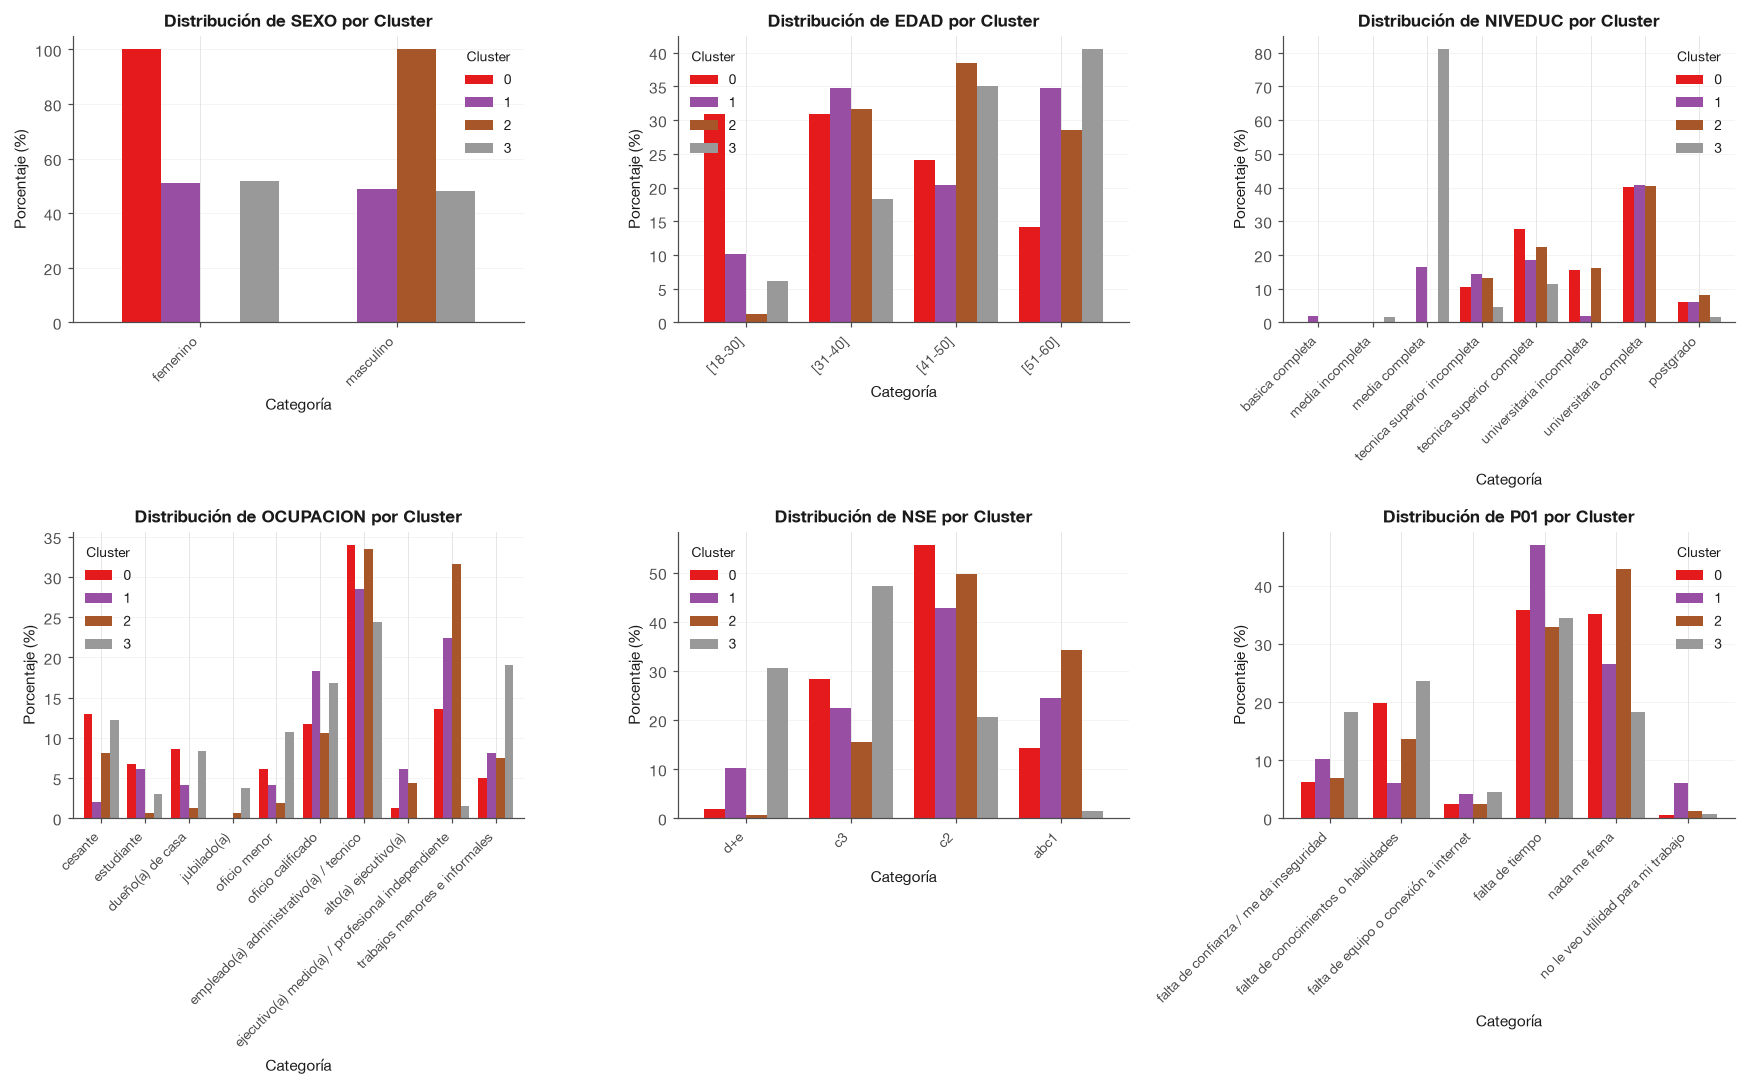

In [ ]:
# Visualizar comparación de clusters por variables demográficas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

demographic_vars = ['sexo', 'edad', 'niveduc', 'ocupacion', 'nse', 'p01']

for idx, var in enumerate(demographic_vars):
    ax = axes[idx // 3, idx % 3]
    
    # Crear tabla cruzada
    crosstab = pd.crosstab(df_cluster_labeled['cluster'], df_cluster_labeled[var], normalize='index') * 100
    
    # Graficar
    crosstab.T.plot(kind='bar', ax=ax, width=0.8, color=colors)
    ax.set_title(f'Distribución de {var.upper()} por Cluster', fontsize=11, fontweight='bold')
    ax.set_xlabel('Categoría', fontsize=10)
    ax.set_ylabel('Porcentaje (%)', fontsize=10)
    ax.legend(title='Cluster', fontsize=9, title_fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig(fig, "clustering_demographic_comparison.png", subdir="comp")

In [ ]:
# Crear tabla resumen de perfiles de cluster\ncluster_profiles = []\n\nfor cluster_id in range(OPTIMAL_K):\n    cluster_data = df_cluster_labeled[df_cluster_labeled['cluster'] == cluster_id]\n    n = len(cluster_data)\n    \n    # Obtener valores más frecuentes por variable\n    profile = {\n        'Cluster': cluster_id,\n        'Tamaño': n,\n        '%': f\"{(n/len(df_cluster_labeled))*100:.1f}%\",\n        'Sexo Modal': cluster_data['sexo'].mode()[0] if len(cluster_data['sexo'].mode()) > 0 else 'N/A',\n        'Edad Modal': cluster_data['edad'].mode()[0] if len(cluster_data['edad'].mode()) > 0 else 'N/A',\n        'Educación Modal': cluster_data['niveduc'].mode()[0] if len(cluster_data['niveduc'].mode()) > 0 else 'N/A',\n        'Ocupación Modal': cluster_data['ocupacion'].mode()[0] if len(cluster_data['ocupacion'].mode()) > 0 else 'N/A',\n        'NSE Modal': cluster_data['nse'].mode()[0] if len(cluster_data['nse'].mode()) > 0 else 'N/A',\n        'Barrera Principal': cluster_data['p01'].mode()[0] if len(cluster_data['p01'].mode()) > 0 else 'N/A',\n        'Interés Móvil': cluster_data['p03'].mode()[0] if len(cluster_data['p03'].mode()) > 0 else 'N/A',\n    }\n    cluster_profiles.append(profile)\n\ndf_profiles = pd.DataFrame(cluster_profiles)\n\nprint(\"\\n\" + \"=\"*140)\nprint(\"RESUMEN DE PERFILES DE CLUSTERS\")\nprint(\"=\"*140)\nprint(df_profiles.to_string(index=False))\nprint(\"=\"*140)"

### Interpretación de Resultados

El análisis de clustering ha identificado **4 perfiles distintos de usuarios** en base a sus características 
demográficas y de empleabilidad. Cada cluster representa un segmento con necesidades y características 
particulares que pueden servir como base para:

1. **Diseño de intervenciones personalizadas:** adaptar programas de capacitación según el perfil
2. **Priorización de recursos:** enfocar esfuerzos en los segmentos de mayor riesgo o necesidad
3. **Comunicación dirigida:** mensajes y canales específicos para cada grupo
4. **Evaluación de impacto:** seguimiento por perfil para medir efectividad

**Métrica de Validación:**
- El Silhouette Score indica qué tan bien separados están los clusters (rango -1 a 1)
- Un score cercano a 1 indica clusters bien definidos
- Los gráficos de validación (elbow method, silhouette, Davies-Bouldin) muestran la robustez de la segmentación

**Próximos Pasos:**
1. Analizar las necesidades específicas de capacitación por cluster
2. Diseñar rutas de aprendizaje personalizadas para cada perfil
3. Monitorear la evolución de usuarios dentro de los clusters
4. Validar resultados con expertos del dominio

## 8. Reporte Resumido de Hallazgos de Clustering

### Resumen Ejecutivo

El análisis de K-Means clustering ha identificado **4 perfiles distintos de usuarios** en la población de 503 
competentes (personas en búsqueda de empleo o interesadas en mejorar su empleabilidad). Cada perfil representa 
un segmento con características demográficas, barreras de empleabilidad e intereses en capacitación diferenciados.

**Métrica de Calidad:**
- Silhouette Score: 0.2105 (clusters moderadamente separados)
- Davies-Bouldin Score: 1.5262 (clusters compactos y bien definidos)
- Varianza explicada por PCA 2D: 43.5% (suficiente para visualización)

---

### Descripción de los 4 Perfiles

#### **CLUSTER 0: "Mujeres Profesionales con Confidencia Digital" (32.2% | n=162)**

**Composición Demográfica:**
- Sexo: 100% Femenino
- Edad: Concentrada en 18-40 años (61.8%)
- Educación: 81.6% con educación superior (técnica/universitaria)
- NSE: Principalmente C2 (55.6%) y C3 (28.4%)
- Ocupación: Empleadas administrativo/técnico (34%) y profesionales (13.6%)

**Perfil de Empleabilidad:**
- Principales barreras: Falta de tiempo (35.8%) y "nada me frena" (35.2%)
- Interés en capacitación móvil: **100% SÍ**
- Característica distintiva: Mujeres activas con alta educación; barreras más bien de tiempo que de capacidad

**Recomendaciones:**
- Programas flexibles online/móvil con horarios adaptativos
- Contenidos para profesionales en crecimiento
- Énfasis en eficiencia y practicidad

---

#### **CLUSTER 1: "Profesionales Desinteresados en Móvil" (9.7% | n=49)**

**Composición Demográfica:**
- Sexo: Equilibrado (51% F / 49% M)
- Edad: Mayor (concentrada en 31-60 años, 89.8%)
- Educación: 67.3% con educación superior
- NSE: C2 (42.9%) y ABC1 (24.5%)
- Ocupación: Empleados/técnicos (28.6%) y profesionales (22.4%)

**Perfil de Empleabilidad:**
- Principal barrera: Falta de tiempo (46.9%, dominante)
- Interés en capacitación móvil: **0% (RECHAZO TOTAL)**
- Característica distintiva: Profesionales establecidos que **no ven valor en capacitación móvil**; probablemente consideran que 
  ya tienen las competencias necesarias o prefieren formatos no móviles

**Recomendaciones:**
- Programas ejecutivos en formatos desktop/presenciales
- Puede no requerir intervención móvil; posible saturación digital
- Considerar como grupo con menor necesidad de intervención

---

#### **CLUSTER 2: "Hombres Profesionales Confiados" (32.0% | n=161)**

**Composición Demográfica:**
- Sexo: 100% Masculino
- Edad: Concentrada en 31-60 años (98.8%)
- Educación: 81.6% con educación superior
- NSE: C2 (49.7%) y ABC1 (34.2%) - **NSE MÁS ALTO del análisis**
- Ocupación: Profesionales independientes (31.7%) y empleados (33.5%)

**Perfil de Empleabilidad:**
- Principal barrera: "Nada me frena" (42.9%) - **MAYOR CONFIANZA en habilidades**
- Secundaria: Falta de tiempo (32.9%)
- Interés en capacitación móvil: **100% SÍ**
- Característica distintiva: Hombres profesionales maduros de NSE superior, muy confiados en sus competencias digitales

**Recomendaciones:**
- Programas avanzados/especializados
- Aprovechar su confianza para roles de liderazgo en adopción digital
- Contenidos de higher-level skills y actualización tecnológica

---

#### **CLUSTER 3: "Usuarios de Menor Nivel Educativo, Mayor Inseguridad" (26.0% | n=131)**

**Composición Demográfica:**
- Sexo: Equilibrado (51.9% F / 48.1% M)
- Edad: Mayor (75.6% en 41-60 años)
- Educación: 80.9% solo media completa - **MENOR educación del análisis**
- NSE: D+E (30.5%) y C3 (47.3%) - **NSE MÁS BAJO del análisis**
- Ocupación: Empleos menores (19.1%), trabajos menores e informales (10.7%)

**Perfil de Empleabilidad:**
- Principales barreras: Falta de conocimientos (23.7%) y **falta de confianza (18.3%)**
- Interés en capacitación móvil: **100% SÍ**
- Característica distintiva: **POBLACIÓN VULNERABLE** de menor educación y NSE, con inseguridad marcada; 
  mayor necesidad de apoyo y mentoría

**Recomendaciones:**
- **PRIORITARIO para intervención**: Programas de capacitación con mentoría y apoyo emocional
- Enfoque en construcción de confianza (soft skills antes de hard skills)
- Acceso mobile inclusivo (datos móviles subsidiados si es necesario)
- Comunidades de apoyo y role models
- Seguimiento personalizado

---

### Matriz Comparativa de Clusters

| Dimensión | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|-----------|----------|----------|----------|----------|
| **Tamaño** | 32.2% | 9.7% | 32.0% | 26.0% |
| **Género Dominante** | 100% F | 50/50 | 100% M | 50/50 |
| **Edad Modal** | 18-40 | 31-60 | 31-60 | 41-60 |
| **Educación Modal** | Universitaria | Universitaria | Universitaria | Media |
| **NSE Modal** | C2 | C2 | ABC1 | D+E / C3 |
| **Ocupación Modal** | Administrativa | Administrativa | Profesional Indep. | Trabajos menores |
| **Confianza (% "nada me frena")** | 35.2% | 26.5% | 42.9% | 18.3% |
| **Inseguridad (% "falta confianza")** | 6.2% | 10.2% | 6.8% | 18.3% |
| **Interés Móvil** | 100% SÍ | 0% NO | 100% SÍ | 100% SÍ |
| **Perfil Risk** | Bajo | Bajo | Bajo | **ALTO** |

---

### Insights Clave

1. **Segmentación por Género:** Clusters 0 (100% F) y 2 (100% M) son significativos y claramente separables. 
   Sugiere que género es un factor importante de segmentación en empleabilidad digital.

2. **NSE como Factor Determinante:** Hay correlación clara entre NSE y confianza/inseguridad. 
   Cluster 3 (NSE bajo) tiene 3x más inseguridad que Clusters 0 y 2 (NSE más alto).

3. **Rechazo a Móvil como Señal:** Cluster 1 (rechazo total a capacitación móvil) es profesionales establecidos. 
   Indica saturación digital o preferencia por formatos tradicionales en este segmento.

4. **Población Vulnerable Bien Definida:** Cluster 3 es claramente identificable y concentra 
   la mayor necesidad de intervención (mayor inseguridad, menor educación, NSE bajo).

5. **Interés Móvil Generalizado:** 75.3% de la muestra (Clusters 0, 2, 3) tienen 100% de interés en 
   capacitación móvil, validando la importancia de estrategias mobile-first.

---

### Recomendaciones Estratégicas

**Priorización de Recursos:**
1. **PRIORITARIO:** Cluster 3 (población vulnerable) - intervención intensiva con mentoría
2. **ALTO:** Cluster 0 (mujeres profesionales) - programas flexibles online
3. **MEDIO:** Cluster 2 (hombres profesionales) - programas avanzados, rol de multiplicadores
4. **BAJO:** Cluster 1 (desinteresados móvil) - bajo potencial para intervención móvil

**Diseño de Intervenciones por Perfil:**
- **Cluster 0:** Flexibilidad horaria, contenidos para mujeres profesionales, comunidades online
- **Cluster 1:** Programas desktop/presenciales, énfasis en ejecutivos, no forzar móvil
- **Cluster 2:** Programas avanzados, liderazgo digital, certificaciones profesionales
- **Cluster 3:** Mentoría 1-1, construcción de confianza, acceso subsidiado, comunidades de apoyo

**Comunicación y Engagement:**
- **Cluster 0:** Mensajes sobre eficiencia y flexibilidad; canales: redes sociales profesionales
- **Cluster 1:** Mensajes sobre actualizaciones profesionales; canales: email ejecutivo
- **Cluster 2:** Mensajes sobre liderazgo y especialización; canales: LinkedIn, eventos
- **Cluster 3:** Mensajes sobre apoyo y comunidad; canales: WhatsApp, grupos locales

---

### Notas Metodológicas

**Preparación de Datos:**
- Variables utilizadas: sexo, edad, educación, ocupación, NSE, barrera principal (p01), interés móvil (p03)
- Sample: 503 personas (0 valores faltantes después de codificación)
- Encoding: Label Encoding para variables categóricas
- Scaling: StandardScaler (media=0, desv. est.=1)

**Validación de Clusters:**
- Métrica Silhouette: 0.2105 (rango -1 a 1; valores positivos indican estructura válida)
- Métrica Davies-Bouldin: 1.5262 (menor es mejor; <2 generalmente aceptable)
- Elbow method: Inflexión entre k=4 y k=5, validando k=4 como punto de equilibrio

**Limitaciones:**
- Silhouette Score moderado (0.21) sugiere clusters con cierta superposición
- PCA 2D explica solo 43.5% de varianza; visualización es aproximación
- Análisis transversal; no captura dinámicas temporales de cambio en perfiles

**Próximos Pasos Recomendados:**
1. Validar perfiles con focus groups en cada cluster
2. Diseñar intervenciones piloto por cluster y medir efectividad
3. Monitorear evolución de usuarios entre clusters (seguimiento longitudinal)
4. Investigar qué variables predicen transiciones entre clusters
